In [1]:
# only multivariable training
# preselections
# 3 classes
# signal (pure)
# beauty (pure)
# background (from data)
# NO REFLECTED (neglegible)
# probability graph by class (for all 3)

# once obtained, analyze pseudo-significance by cuts 
# create a new training set, analyze cuts for signal and beauty
# this can be done sequentially, fix signal first, then beauty at fixed signal

# compute efficiency

# save selected data for remaining dataset 0 in a file
# run model and cut for all chunks and save other data files

# once done over all data, load all and analyze toughether

In [2]:
import copy
import numpy as np
import pandas as pd
import uproot as ur
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter, AutoMinorLocator, MultipleLocator, FuncFormatter

# XGBoost 
import xgboost as xgb
from xgboost import XGBClassifier # this is an API from Scikit-Learn
from xgboost import plot_importance # and this is a Plot API
#, to_graphviz, plot_tree hope we don't need those

# for the optimization of the parameters
# to perform Kfold
from sklearn.model_selection import KFold 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, RocCurveDisplay, roc_curve, roc_auc_score, auc
# used in the ROC curve analysis
from sklearn.preprocessing import LabelBinarizer # maybe this can be an alternative to multiclass

# from hyperopt import tpe, hp, fmin, Trials, STATUS_OK
from hyperopt import tpe, hp, fmin, Trials, STATUS_OK, space_eval
# from hpsklearn import HyperoptEstimator, xgboost_classification

import shap


print("XGBoost version:", xgb.__version__)

XGBoost version: 3.0.4


In [3]:
# setting random seed for reproducibility
np.random.seed(2150237)
# I don't know if the numpy interface is more efficient or only more resources consuming
numpy_interface = True
# preliminary Y cut, to be seen
fY_cut = 0.8
# number of signal points to include in the training
signal_points = 2e+4
# this is used to change the backround to signal ratio (1:1 suggested)
bg_signal = 1
# deciding how many dataframe to use for the background data sampling
double_df = False
# double_df = True

In [4]:
# these are the lists we use for selecting columns and train
# base xgboost training
train_columns_D0 = [ 
                     'fChi2PCA', 
                     'fDecayLength', 
                     'fDecayLengthXY', 
                     'fImpactParameter0', 
                     'fImpactParameter1',
                     'fImpactParameterProduct',
                     'fCpa',
                     'fCpaXY'
                   ]
# extended xgboost training
train_columns_D0_extra = [ 
                     'fChi2PCA', 
                     'fDecayLength', 
                     'fDecayLengthXY', 
                     'fImpactParameter0', 
                     'fImpactParameter1',
                     'fImpactParameterProduct',
                     'fCpa',
                     'fCpaXY',
                     'fNSigTpcPi0' ,
                     'fNSigTpcKa0' ,
                     'fNSigTofPi0' ,
                     'fNSigTofKa0' ,
                     'fNSigTpcTofPi0' ,
                     'fNSigTpcTofKa0' ,
                     'fNSigTpcPi1' ,
                     'fNSigTpcKa1' ,
                     'fNSigTofPi1' ,
                     'fNSigTofKa1' ,
                     'fNSigTpcTofPi1' ,
                     'fNSigTpcTofKa1' 
                   ]
# base xgboost training
train_columns_LC = [ 
                     'fChi2PCA', 
                     'fDecayLength', 
                     'fDecayLengthXY', 
                     'fImpactParameter0', 
                     'fImpactParameter1',
                     'fImpactParameter2',
                     'fCpa',
                     'fCpaXY',
                     'fCt'
                   ]
# extended xgboost training
train_columns_LC_extra = [ 
                     'fChi2PCA', 
                     'fDecayLength', 
                     'fDecayLengthXY', 
                     'fImpactParameter0', 
                     'fImpactParameter1',
                     'fImpactParameter2',
                     'fCpa',
                     'fCpaXY',
                     'fCt',
                     'fNSigTpcPi0' ,
                     'fNSigTpcPr0' ,
                     'fNSigTofPi0' ,
                     'fNSigTofPr0' ,
                     'fNSigTpcKa1' ,
                     'fNSigTofKa1' ,
                     'fNSigTpcPi2' ,
                     'fNSigTpcPr2' ,
                     'fNSigTofPi2' ,
                     'fNSigTofPr2' ,
                     'fNSigTpcTofPi0' ,
                     'fNSigTpcTofPr0' ,
                     'fNSigTpcTofKa1' ,
                     'fNSigTpcTofPi2' ,
                     'fNSigTpcTofPr2' 
                   ]
# minimum for xgboost
DZ_columns_base = [
                    'fChi2PCA',
                    'fDecayLength',
                    'fDecayLengthXY',
                    'fImpactParameter0',
                    'fImpactParameter1',
                    'fCpa',
                    'fCpaXY',
                    'fM',
                    'fPt',
                    'fY',
                    'fOriginMcRec',
                    'fImpactParameterProduct',
                    'fCandidateSelFlag',
                    'fFlagMc'
]
# extended xgboost option, maybe for preselection
DZ_columns_ex = [
                    'fChi2PCA',
                    'fDecayLength',
                    'fDecayLengthXY',
                    'fImpactParameter0',
                    'fImpactParameter1',
                    'fCpa',
                    'fCpaXY',
                    'fM',
                    'fPt',
                    'fY',
                    'fOriginMcRec',
                    'fImpactParameterProduct',
                    'fCandidateSelFlag',
                    'fFlagMc',
                    'fNSigTpcPi0' ,
                    'fNSigTpcKa0' ,
                    'fNSigTofPi0' ,
                    'fNSigTofKa0' ,
                    'fNSigTpcTofPi0' ,
                    'fNSigTpcTofKa0' ,
                    'fNSigTpcPi1' ,
                    'fNSigTpcKa1' ,
                    'fNSigTofPi1' ,
                    'fNSigTofKa1' ,
                    'fNSigTpcTofPi1' ,
                    'fNSigTpcTofKa1' 
]

# minimum for xgboost
LC_columns_base = [
                    'fChi2PCA',
                    'fDecayLength',
                    'fDecayLengthXY',
                    'fImpactParameter0',
                    'fImpactParameter1',
                    'fImpactParameter2' ,
                    'fCpa',
                    'fCpaXY',
                    'fCt',
                    'fM',
                    'fPt',
                    'fY',
                    'fOriginMcRec'
]
# extended xgboost option, maybe for preselection
LC_columns_ex = [
                    'fChi2PCA',
                    'fDecayLength',
                    'fDecayLengthXY',
                    'fImpactParameter0',
                    'fImpactParameter1',
                    'fImpactParameter2' ,
                    'fCpa',
                    'fCpaXY',
                    'fCt',
                    'fM',
                    'fPt',
                    'fY',
                    'fOriginMcRec',
                    'fCandidateSelFlag',
                    'fNSigTpcPi0' ,
                    'fNSigTpcPr0' ,
                    'fNSigTofPi0' ,
                    'fNSigTofPr0' ,
                    'fNSigTpcKa1' ,
                    'fNSigTofKa1' ,
                    'fNSigTpcPi2' ,
                    'fNSigTpcPr2' ,
                    'fNSigTofPi2' ,
                    'fNSigTofPr2' ,
                    'fNSigTpcTofPi0' ,
                    'fNSigTpcTofPr0' ,
                    'fNSigTpcTofKa1' ,
                    'fNSigTpcTofPi2' ,
                    'fNSigTpcTofPr2' 
]

In [5]:
# to divide the dataset and set labels we can use a dictionary, order sensitive, with name and value
default_labels = {
    'Background' : 0,
    'Signlal'    : 1,
    'Beauty'     : 2,
    # 'Reflected' : 3
}

In [6]:
# 1) Produce the best dataframe for the analysis
# 2) Divide the dataset into Training, Test (and other for later)
# for Y LC we use
#  0 for the Background
#  1 for Signal with Beauty Origin (they are signal in the end..)
#  2 for Signal

# for Y D0 we use
#  0 for the Background
#  1 for Signal with Beauty Origin (they are signal in the end..)
#  2 for D0 and !D0 mislabeling (they are near signal but..)
#  3 for Signal

def get_Train( train_columns, MC_df, Data_df = None, signal_size = 1e+4, seed = 2150237, labels = default_labels, bg_fraction = bg_signal ) :
    # computing the fraction of training signal over the total of MC data
    signal_fraction = signal_size / len( MC_df )

    # the list of label names
    keys = list( labels.keys() )

    if( 'Signal' in keys ) :
        Signal_value = labels[ 'Signal' ]
    else :
        Signal_value = 1
    # creating Y label for the MC dataset
    MC_Y = pd.Series( np.repeat( Signal_value, len( MC_df ) ), index = MC_df.index )
    for key in keys :
        if key == 'Beauty' :
            MC_Y[ MC_df[ 'fOriginMcRec' ] == 2 ] = labels[ key ]
        if key == 'Reflected' :
            # this mask select as the same all D0 and !D0 mislabeling
            mask = ( 3 - 2 * MC_df[ 'fCandidateSelFlag' ] - MC_df[ 'fFlagMc' ] ).ne( 0 )
            MC_Y[ mask ] = labels[ key ]
        # if key == 'D0as!D0' :
        #     # this mask select all D0 wrongly classifed as anti D0
        #     mask = ( 3 - 2 * MC_df[ 'fCandidateSelFlag' ] - MC_df[ 'fFlagMc' ] ).eq( 2 )
        #     MC_Y[ mask ] = labels[ key ]
        # if key == '!D0asD0' :
        #     # this mask select all anti D0 wrongly classifed as D0
        #     mask = ( 3 - 2 * MC_df[ 'fCandidateSelFlag' ] - MC_df[ 'fFlagMc' ] ).eq( -2 )
        #     MC_Y[ mask ] = labels[ key ]
    
    MC_train_df_X, MC_test_df_X, MC_train_df_Y, MC_test_df_Y = train_test_split( MC_df, MC_Y, 
                                                                                train_size = signal_fraction, random_state = seed )
    # this function can be used to add the data background or not
    if 'Background' in keys :
        # backgrouns size should be ~ signal
        bg_size = bg_fraction * signal_size
        signal_fraction = bg_size / len( Data_df )
        Y =  pd.Series( np.repeat( labels[ 'Background' ], len( Data_df ) ), index = Data_df.index )
        Data_train_df_X, Data_test_df_X, Data_Y, Data_test_Y = train_test_split( 
                                                                Data_df, Y, train_size = signal_fraction, random_state = seed )
        MC_test_df_X[ 'fLabel' ]   = MC_test_df_Y
        Data_test_df_X[ 'fLabel' ] = Data_test_Y
        # creating an extended test data frame sampled as the same dimension of training set
        Extended_test_df = pd.concat( [ MC_test_df_X , Data_test_df_X ] )
        # Extended_test_df[ 'fLabel' ] = pd.concat( [ MC_test_df_Y, Data_test_Y ] )
        if( numpy_interface ) :
            Y = pd.concat( [ MC_train_df_Y, Data_Y ] ).to_numpy()
            X = pd.concat( [ MC_train_df_X[ train_columns ], Data_train_df_X[ train_columns ] ] ).to_numpy()
        else :
            Y = pd.concat( [ MC_train_df_Y, Data_Y ] )
            X = pd.concat( [ MC_train_df_X[ train_columns ], Data_train_df_X[ train_columns ] ] )
    else :
        Data_test_df_X = None
        Extended_test_df = None
        MC_test_df_X[ 'fLabel' ] = MC_test_df_Y
        if( numpy_interface ) :
            Y = MC_train_df_Y.to_numpy()
            X = MC_train_df_X[ train_columns ].to_numpy()
        else :
            Y = MC_train_df_Y
            X = MC_train_df_X[ train_columns ]

    # show the composition of the dataset
    data_size = Y.shape[ 0 ]
    print( f"The Training Dataframe consist in {data_size} particles:")
    for key in keys :
        fraction = np.sum( Y == labels[ key ] ) / data_size
        print( f"   - {(fraction * 100):.1f}% {key}")
        
    return X, Y, MC_test_df_X, Data_test_df_X, Extended_test_df


# generalize to exclude particle and use columns instead

def predict_df( model, df, train_columns, mode = 'class' ) :
    if( numpy_interface ) :
        X = df[ train_columns ].to_numpy()
    else :
        X = df[ train_columns ]
    if( mode == 'class' ) :
        Y = model.predict( X )
    else :
        Y = model.predict_proba( X )
    return Y


In [7]:
# get and ready df for compact and maybe efficiency scope
def get_cut_df( path, select_columns, pt_int = (0,2), fY_cut = fY_cut, M_int = None, cuts = None, particle = 'D0' ) :
    # df_file = ur.open( path )
    with ur.open( path ) as df_file :
        if particle == 'D0' :
            df_tree = df_file.keys( filter_classname = 'TTree' )
        else :
            df_tree = df_file.keys( filter_name = r'*O2hfcandlclite' )
    
    
        # using a complete cut for the selection
        final_cut = f"( ( fPt > {pt_int[0]} ) & ( fPt < {pt_int[1]} ) ) & ( ( fY > {-fY_cut} ) & ( fY < {fY_cut} ) ) "
        if M_int is not None :
            final_cut += f" & ( ( fM > {M_int[0]} ) & ( fM < {M_int[1]} ) )"
        if cuts is not None :
            final_cut += f' & ( {cuts} )' 
        # optimal cuts can be performed directly here as ( cuts are the same of pandas execute )
        df_list = [ df_file[ tree_i ].arrays( select_columns, final_cut, library = 'pd' ) for tree_i in df_tree ]
    df_fine = pd.concat( df_list )
    del df_list
    return df_fine


def ready_cut_df( MC_df, train_columns, labels, Data_df = None, peack_int = (1.815, 1.915), 
                  # signal_size = signal_points, bg_fraction = bg_signal, particle = 'D0' ) :
                  signal_size = signal_points, bg_fraction = bg_signal ) :
    # this function can be used to add the data background or not
    if 'Background' in list( labels.keys() ) :
        # # try to reduce the background region near the peack
        # half_left = peack_int[ 0 ] /2 + Data_df[ 'fM' ].min() / 2
        # half_right = peack_int[ 1 ] /2 + Data_df[ 'fM' ].max() / 2
        # mask = Data_df[ 'fM' ].between( half_left, peack_int[0] ) | Data_df[ 'fM' ].between( peack_int[1], half_right )

        # # 1.5) Divide Data into "background" and "signal" region for training
        # Data_df_0 = Data_df.loc[ mask ]
        # # the other data part is useful for the second analysis
        # Data_peack_0 = Data_df.loc[ ~mask ]

        
        # 1.5) Divide Data into "background" and "signal" region for training
        Data_df_0 = Data_df.loc[ ~Data_df[ 'fM' ].between( peack_int[0], peack_int[1] ) ]
        # the other data part is useful for the second analysis
        Data_peack_0 = Data_df.loc[ Data_df[ 'fM' ].between( peack_int[0], peack_int[1] ) ]

        # 2) Divide the dataset into Training, Test (and other for later)
        X_0, Y_0, MC_Test_0, DATA_Test_0, Extended_test = get_Train( train_columns, MC_df, Data_df_0, signal_size = signal_size, 
                                                                     labels = labels, bg_fraction = bg_fraction )
        # reconstruct remaining data
        Data_Test_0 = pd.concat( [ DATA_Test_0, Data_peack_0 ] )
    else :
        X_0, Y_0, MC_Test_0, _ , _ = get_Train( train_columns, MC_df, signal_size = signal_size, 
                                                labels = labels, bg_fraction = bg_fraction )
        Data_Test_0 = None
        Extended_test = MC_Test_0


    # # removing reflected components from the training set (should be already reduced by cuts)
    # # but not removing it from the efficiency computation
    if 'Reflected' in list( labels.keys() ):
            mask = Y_0 != labels[ 'Reflected' ]
            X_0 = X_0[ mask ]
            Y_0 = Y_0[ mask ]
            Extended_test = Extended_test[ Extended_test[ 'fLabel' ] != labels[ 'Reflected' ] ]
        
    # if particle == 'D0' :
    #     # this mask select as the same all D0 and !D0 mislabeling
    #     mask = ( 3 - 2 * MC_df[ 'fCandidateSelFlag' ] - MC_df[ 'fFlagMc' ] ).eq( 0 )
    #     MC_df = MC_df[ mask ]
        
    return X_0, Y_0, MC_Test_0, Data_Test_0, Extended_test

In [8]:
# function to subcut dataframe in pt range and extrapolate a sample
def test_df( df, labels, pt_int,  signal_size = None, Y_key = 'fLabel' ) :
    if signal_size is None :
        signal_size = { lab : 1e+4 for lab in labels }
    # getting a list of df for each label in labels, with the correct Pt range and getting a specific sample of each label
    cutted_list = [ df[ ( df[Y_key] == labels[lab] ) & ( df[ 'fPt' ] > pt_int[0] ) & ( df[ 'fPt' ] < pt_int[1] ) ].sample( n = int( signal_size[ lab ] ) ) for lab in labels ]
    final_df = pd.concat( cutted_list )
    # getting a equal distributed sample of each label
    # final_df = pd.concat( [ dataframe.sample( n = int( signal_size[ lab ] ) ) for dataframe in cutted_list] )
    return final_df

In [9]:
# function to get the different classes based on probability specific cuts
def classify_df( model, df, train_columns, labels, cuts ) :
    if( numpy_interface ) :
        X = df[ train_columns ].to_numpy()
    else :
        X = df[ train_columns ]
    Y_prob = model.predict_proba( X )
    # instead of the direct prediction we use a cut over the probability of each class
    # we decide to use the background as the default value and change if conditions are met, 
    # or the beauty signal if BG is not present
    classes = list( cuts.keys() )
    bg_key = 'Background' if 'Background' in classes else ( 'Reflected' if 'Reflected' in classes else 'Beauty' )
    if numpy_interface :
        Y = np.repeat( labels[ bg_key ], len( df ) )
    else :
        Y = pd.Series( np.repeat( labels[ bg_key ], len( df ) ), index = df.index )
    # track background probability
    bg_id = np.flatnonzero( model.classes_ == labels[ bg_key ] )[0]
    # cycling over keys in cuts; by construction later keys override
    prob_bg = Y_prob[ :, bg_id ]
    for main in classes :
        # exclude the background key
        if main == bg_key : continue
        class_id = np.flatnonzero( model.classes_ == labels[ main ] )[0]
        prob = Y_prob[ :, class_id ]
        Y[ ( prob > cuts[ main ] ) & ( prob_bg < cuts[ bg_key ] ) ] = labels[ main ]
    # this now is made of background keys except elements with grater probability
    return Y

# function to cut the df accordign to the trained probabilities
def xgcut_df( model, df, train_columns, labels, cuts, mode = 'cut' ) :
    if( numpy_interface ) :
        X = df[ train_columns ].to_numpy()
    else :
        X = df[ train_columns ]
    Y_prob = model.predict_proba( X )
    # instead of the direct prediction we use a cut over the probability of each class
    # we can decide to cut over signal and remove other
    # or cut under other threshold
    classes = list( cuts.keys() )
    if 'Signal' in classes :
        if numpy_interface :
            Y = np.repeat( False, len( df ) )
        else :
            Y = pd.Series( np.repeat( False, len( df ) ), index = df.index )
        signal_id = np.flatnonzero( model.classes_ == labels[ 'Signal' ] )[0]
        prob = Y_prob[ :, signal_id ]
        Y[ prob > cuts[ 'Signal' ] ] = True
    else :
        if numpy_interface :
            Y = np.repeat( True, len( df ) )
        else :
            Y = pd.Series( np.repeat( True, len( df ) ), index = df.index )
    # cycle over other classes and remove the cutted out entries
    for main in classes :
        # exclude the signal key
        if main == 'Signal' : continue
        class_id = np.flatnonzero( model.classes_ == labels[ main ] )[0]
        prob = Y_prob[ :, class_id ]
        Y[ prob > cuts[ main ] ] = False
    # this now is made as a mask of True (for signal)
    # except elements with grater probability for other classes
    # two return types, the mask and the cut df
    if mode == 'mask' :
        return Y
    else :
        return df[Y]

In [10]:
# 3.5) Optimization: can be done, but maybe after having tried the model to see how much time it needs

def model_optimize( X, Y, train_columns, random_seed = 2150237, Ksplit = 10, verbose = True ) :

    # we could in teory generalize to binary and multiclass
    if numpy_interface :
        binary = np.unique( Y ).shape[0] == 2
        Nclass = np.unique( Y ).shape[0]
    else :
        binary = len( Y.unique() ) == 2
        Nclass = len( Y.unique() )
    
    # define choice list outside for later utility
    eval_list = [ 'rmse', 'rmsle', 'mae', 'logloss', 'error', 'map', 'auc' ] if binary else [ 'mlogloss', 'merror', 'auc' ]
    imp_list  = [ 'gain', 'weight', 'cover', 'total_gain', 'total_cover' ]
    obj_list  = [ 'binary:logistic', 'binary:logitraw', 'binary:hinge' ]
    
    # define hyperparameter search space
    search_space = {
            'grow_policy' : 'lossguide',
            'random_state' : 2150237,
            'verbosity' : 0,
            'validate_parameters' : True,
            'eval_metric' : hp.choice( 'eval_metric', eval_list ), 
            'n_estimators' : hp.uniformint( 'n_estimators', 10, 50 ),
            'max_depth' : hp.uniformint( 'max_depth', 0, 15 ),
            'max_leaves': hp.uniformint( 'max_leaves', 0, 10 ),
            'learning_rate' : hp.loguniform( 'learning_rate', -2, 0 ),
            'gamma' : hp.uniform( 'gamma', 0, 0.5 ),
            'min_child_weight' : hp.uniformint( 'min_child_weight', 0, 10 ),
            'max_delta_step' : hp.uniformint( 'max_delta_step', 1, 20 ),
            'reg_alpha' : hp.uniform( 'reg_alpha', 0.0, 1.0 ),
            'reg_lambda' : hp.uniform( 'reg_lambda', 0.0, 1.0 ),
            'importance_type' : hp.choice( 'importance_type', imp_list ),
            'objective' :  hp.choice( 'objective', obj_list ),
            'enable_categorical' : True,
            'feature_names' : train_columns
        } if binary else {
            'grow_policy' : 'lossguide',
            'objective' : 'multi:softmax',
            'num_class' : Nclass,
            'random_state' : 2150237,
            'verbosity' : 0,
            'validate_parameters' : True,
            'eval_metric' : hp.choice( 'eval_metric', eval_list ), 
            'n_estimators' : hp.uniformint( 'n_estimators', 10, 50 ),
            'max_depth' : hp.uniformint( 'max_depth', 0, 15 ),
            'max_leaves': hp.uniformint( 'max_leaves', 0, 10 ),
            'learning_rate' : hp.loguniform( 'learning_rate', -2, 0 ),
            'gamma' : hp.uniform( 'gamma', 0, 0.5 ),
            'min_child_weight' : hp.uniformint( 'min_child_weight', 0, 10 ),
            'max_delta_step' : hp.uniformint( 'max_delta_step', 1, 20 ),
            'reg_alpha' : hp.uniform( 'reg_alpha', 0.0, 1.0 ),
            'reg_lambda' : hp.uniform( 'reg_lambda', 0.0, 1.0 ),
            'importance_type' : hp.choice( 'importance_type', imp_list),
            'enable_categorical' : True,
            'feature_names' : train_columns
        }
    
    # create kfold to optimize training
    kf = KFold( n_splits = Ksplit, shuffle = True, random_state = 2150237 )
    best_score = -1
    best_hyperparams = None
    # train over k folds to get the best model
    for i, ( train_id, eval_id ) in enumerate( kf.split( X ) ) :
        X_train_f, Y_train_f = X[ train_id ], Y[ train_id ]
        X_eval_f, Y_eval_f = X[ eval_id ], Y[ eval_id ]
        if verbose : print( f"kFold training, fold {i}:")

         # define the objective function
        def objective( space ):
            # create the classifier
            clf = XGBClassifier( **space )
            
            clf.fit( X_train_f, Y_train_f,
                    eval_set = [( X_train_f, Y_train_f), ( X_eval_f, Y_eval_f)],
                    verbose = False )
            
            accuracy = clf.score( X_eval_f, Y_eval_f )
            return {'loss': -accuracy, 'status': STATUS_OK }
    
        trials = Trials()
        
        hyperparams = fmin(  fn = objective,
                             space = search_space,
                             algo = tpe.suggest,
                             max_evals = 100,
                             trials = trials )

        # for some reasons this does not work properly, so some things have to be manually corrected
        # (this could have been done differently but not too much)
        hyperparams[ 'grow_policy' ]         = 'lossguide'
        hyperparams[ 'random_state']         = 2150237
        hyperparams[ 'verbosity'   ]         = 0
        hyperparams[ 'validate_parameters' ] = True
        hyperparams[ 'enable_categorical' ]  = True
        hyperparams[ 'feature_names' ]       = train_columns
        hyperparams[ 'eval_metric' ]         = eval_list[ hyperparams[ 'eval_metric' ] ]
        hyperparams[ 'importance_type' ]     = imp_list[  hyperparams[ 'importance_type' ] ]
        hyperparams[ 'max_delta_step' ]      = int( hyperparams[ 'max_delta_step' ] )
        hyperparams[ 'max_depth' ]           = int( hyperparams[ 'max_depth' ] )
        hyperparams[ 'max_leaves' ]          = int( hyperparams[ 'max_leaves' ] )
        hyperparams[ 'min_child_weight' ]    = int( hyperparams[ 'min_child_weight' ] )
        hyperparams[ 'n_estimators' ]        = int( hyperparams[ 'n_estimators' ] )
        if binary :
            hyperparams[ 'objective' ]       = obj_list[  hyperparams[ 'objective' ] ]
        else :
            hyperparams[ 'objective' ]       = 'multi:softmax'
            hyperparams[ 'num_class']        = Nclass
        

        
        model = XGBClassifier( **hyperparams )
        model.fit( X_train_f, Y_train_f, verbose = False, eval_set = [( X_train_f, Y_train_f), ( X_eval_f, Y_eval_f)] )
        score = model.score( X_eval_f, Y_eval_f )
        if verbose : print( f"   Fold Score: {score:.4f}\n")
        if( score > best_score ) :
            best_hyperparams = copy.deepcopy( hyperparams )
            best_score = score

    if verbose : print( f"Best hyperparameters found:\n{best_hyperparams}")
    return best_hyperparams
    
    
    # WIP, HYPEROPT DOES NOT WORK DIRECTLY (UNF)
    # define the hyperopt estimator
    # estim = HyperoptEstimator(
    #     classifier = XGBClassifier( 'xgb_class', **search_space ),
    #     preprocessing = [],
    #     algo = tpe.suggest,
    #     max_evals = 50,
    #     trial_timeout = 1e+3,
    #     seed= random_seed
    # )

    # fit to find best hyperparametes
    # estim.fit( X, Y )
    
    # get the best model obtained (as instruction dictionary)
    # return estim.best_model()
    

In [11]:
# 4) Train the model


def model_training( X, Y, Ksplit, model_dict, noise = False, main_graph = 'Signal', graph_dic = default_labels ) :
    # create mode from aguments, directly or from dictionary output
    model = xgb.XGBClassifier( **model_dict )
    # create kfold to optimize training
    kf = KFold( n_splits = Ksplit, shuffle = True, random_state = 2150237 )
    best_score = -1
    best_model = None
    # train over k folds to get the best model
    for i, ( train_id, eval_id ) in enumerate( kf.split( X ) ) :
        X_train_f, Y_train_f = X[ train_id ], Y[ train_id ]
        X_eval_f, Y_eval_f = X[ eval_id ], Y[ eval_id ]
        if noise : print( f"kFold training, fold {i}:")
        model.fit( X_train_f, Y_train_f, verbose = False, eval_set = [( X_train_f, Y_train_f), ( X_eval_f, Y_eval_f)] )
        score = model.score( X_eval_f, Y_eval_f )
        if noise : print( f"   Fold Score: {score:.4f}\n")
        if( score > best_score ) :
            best_model = copy.deepcopy( model )
            best_score = score
        if( noise ) :
            classifier_distribution( model, X_train_f, Y_train_f, X_eval_f, Y_eval_f, main = main_graph, labels = graph_dic )
    best_model.fit( X, Y, verbose = False )
    return best_model, best_score
    
# the result can be saved on a file, and then loaded as trained model (as operative, but a new fit will produce a different model)
# the saved model store the necessary informations to classify but not to train again!
# model.save_model('.json')
# model.load_model('.json')
# model.save_model('.ubj')
# model.load_model('.ubj')


In [12]:
# train envelope to get best model and results
def complete_train( X_0, Y_0, Test_0, train_columns, labels, main = 'Signal', noise = True ) :
    
    # 3) Get the Optimized Model
    model_dic = model_optimize( X_0, Y_0, train_columns, verbose = noise )
    # 4) Train the model
    model, score = model_training( X_0, Y_0, Ksplit = 10, model_dict = model_dic, 
                                    # noise = noise, main_graph = main, graph_dic = labels )
                                    noise = False, main_graph = main, graph_dic = labels )
    print( f"Model Trained with a score of {score:.5f}")
    
    # 5) Test model and performances
    conf_matrix = model_performances( model, Test_0, train_columns,  labels = labels, main = main, verbose = noise )
    if noise :
        importance_graph( model, train_columns )
        beeswarm( model, X_0, train_columns, main = main, dic = labels )
        # ROC curves
        ROC_curves( model, X_0, Y_0, train_columns, main = main, labels = labels, mode = 'OneVsRest', Y_key = 'fLabel' )
        if( len( labels ) > 2 ) :
            ROC_curves( model, X_0, Y_0, train_columns, main = main, labels = labels, mode = 'OneVsRestAll', Y_key = 'fLabel' )
            ROC_curves( model, X_0, Y_0, train_columns, main = main, labels = labels, mode = 'OneVsOne', Y_key = 'fLabel' )

    # this should be all return needed
    return model, conf_matrix

In [13]:
# 5) Test model and performances

# the model performances are computed for the model over the dataframe of unused candidates of training
# we work with the assumption that the Y key is present in the dataframe as fLabel
def model_performances( model, df, train_columns, Y_key = 'fLabel',
                        labels = { 'Background' : 0, 'Signal' : 1 }, main = 'Signal', verbose = True ) :
    # we can work with the real labels compared with the predicted labels
    # if we used numpy arrays, we should convert into numpy also the real labels, otherwise the result has to be converted
    Y_true = df[ Y_key ].to_numpy()
    if( numpy_interface ) :
        Y_pred = predict_df( model, df, train_columns  )
    else : 
        Y_pred = predict_df( model, df, train_columns  ).to_numpy()
    # let's get and store the dimension
    N = Y_true.shape[ 0 ]

    
    # for the multiclass classification we used a dictionary to define labels
    # we could do more confusion matrices but the important part is detecting the signal
    # we call it signal here but in teory could work with any class
    Signal_v = labels[ main ]
    # we can use a mask to get the real positive and negative, also false positive and negative
    true_signal = ( Y_true == Signal_v )
    true_other  = ( Y_true != Signal_v )
    pred_signal = ( Y_pred == Signal_v )
    pred_other  = ( Y_pred != Signal_v )
    # a True Negative is not signal neihter in real nor predicted
    TN = sum( true_other  & pred_other  )
    # a True Positive is a signal for both vectors
    TP = sum( true_signal & pred_signal )
    # a False Positive is not a real signal but a predicted one
    FP = sum( true_other  & pred_signal )
    # a False Negative is a real signal but not predicted as one
    FN = sum( true_signal & pred_other  )

    confusion_matrix = np.array( [ [ TN, FP ], [ FN, TP ] ] )
    norm_conf_matrix = confusion_matrix / N 
    # just a fancy way to display the matrix
    matrix = pd.DataFrame( norm_conf_matrix, columns = pd.MultiIndex.from_product([['Assigned Label'],[ 'Background', main]]),
                       index= pd.MultiIndex.from_product([['Real Label'],['Background', main]]))
    conf_matrix = matrix.style.format('{:.3f}').set_table_styles([
                            {'selector': 'th:not(.index_name)','props': 'background-color: #000066; color: white;'},
                            {'selector': 'th.col_heading', 'props': 'text-align: center;'},
                            {'selector': 'td', 'props': 'text-align: center; font-weight: bold;'},
                            {'selector': '.true', 'props': 'background-color: #e6ffe6;'},
                            {'selector': '.false', 'props': 'background-color: #ffe6e6;'},
                            ], overwrite=False).set_td_classes(pd.DataFrame([['true', 'false'],['false', 'true']], 
                                                                            index = matrix.index, columns = matrix.columns))
    

    accuracy  = ( TP + TN ) / N
    precision = TP / ( TP + FP )
    recall    = TP / ( TP + FN )

    if verbose :
        print( f"Metrics computed with respect to {main} label in the training (value {labels[ main ]}):\n")
        print( f"Confusion Matrix:\n   TN:{confusion_matrix[0,0]}   FP:{confusion_matrix[0,1]}\n   FN:{confusion_matrix[1,0]}   TP:{confusion_matrix[1,1]}\n")
        print( f"Normalized Confusion Matrix:\n   {norm_conf_matrix[0,0]:.3f}   {norm_conf_matrix[0,1]:.3f}\n   {norm_conf_matrix[1,0]:.3f}   {norm_conf_matrix[1,1]:.3f}\n")
        print( f"Accuracy:    {accuracy:.4f}\n")
        print( f"Precision:   {precision:.4f}\n")
        print( f"Recall:      {recall:.4f}\n")
    return conf_matrix

In [14]:
# Here there is all the graphical part [... DATA ARE ACQUIRED BEFORE ...]

# here feats are the training columns
def importance_graph( model, feats, importance = None, complete = True ) :
    # this can be used to display any importance type, default the selected one
    if( importance == None ) :
        importance = model.importance_type

    # display selected and all features
    if( complete ) : 
        fig, axs = plt.subplots( nrows = 2, ncols = 1, figsize = ( 8, 20 ) )
        ax = axs[ 0 ]
    else :
        fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = ( 8, 10 ) )
    
    # plotting the specific importance
    F = len( feats )
    ax.barh( feats, model.feature_importances_,  color =  plt.get_cmap( 'jet' )( np.arange( F ) / F ) )
    ax.xaxis.set_minor_locator(AutoMinorLocator( 5 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.set_title( importance )
    ax.set_xlabel( 'Feature Importance Score' )
    ax.set_ylabel( 'Feature' )
    
    # plotting all importances if requested
    if( complete ) :
        ax = axs[ 1 ]
        imp_list = [ 'gain', 'weight', 'cover', 'total_gain', 'total_cover' ]
        N = len( imp_list )
        colors = plt.get_cmap( 'jet' )( np.arange( N ) / ( N - 0.9 ) )
        for i, im in enumerate( imp_list ) :
            # preventing 0 score features issue
            feat_score = np.array([ model.get_booster().get_score( importance_type = im ).get( f"f{i}", 0 ) for i in range( F ) ])
            feat_score = feat_score/feat_score.sum()
            ax.barh( np.arange( F ) + i / ( 1.5 * N ) - 0.5, feat_score, color = colors[ i ], height = 0.125, label = im )
        ax.xaxis.set_minor_locator(AutoMinorLocator( 5 ))
        ax.set_yticks( np.arange( F ), feats )
        ax.tick_params( which = 'major', direction = 'in', length = 4, width = 1.0 )
        ax.tick_params( which = 'minor', direction = 'in', length = 2, width = 0.5 )
        ax.set_title( 'Importances' )
        ax.set_xlabel( 'Feature Importance Score' )
        ax.set_ylabel( 'Feature' )
        ax.legend( )
    plt.show()
    return

In [15]:
# for SHAP, model trained over X
# here names are train_columns
def beeswarm( model, X, names, main = 'Signal', dic = default_labels ) :
    # compute SHAP values
    explainer = shap.Explainer( model, X, feature_names = names )
    shap_values = explainer( X )
    if ( len( shap_values.shape ) < 3 ) or ( shap_values.shape[ 2 ] == 1 ) :
        ax = shap.plots.beeswarm( shap_values, show = False, max_display = len( names ), color = plt.get_cmap("cool") )
    else :
        ax = shap.plots.beeswarm( shap_values[:,:,dic[main]], show = False, max_display = len( names ), color = plt.get_cmap("cool") )
    ax.set_title( f'{main} data' )
    plt.show()
    return


In [16]:
# ROC curve with two possible approaches for multiclass classification: One Vs One or One Vs Rest
# it is possible to call 
# - OneVsRest: show a specific class Vs all other toghther
# - OneVsRestAll: show for each class OneVsRest, the Micro-Averaged and Macro-Averaged OneVsRest and a single graph 
# - OneVsOne: show a specific class Vs all other singularly taken
# def ROC_curves( model, X_train, Y_train, particle, train_columns, main = None, mode = 'OneVsRest', Y_key = 'fLabel' ) :
def multi_ROC_curve( model, X_train, Y_train, train_columns, main = 'Signal', labels = default_labels, mode = 'OneVsRest', Y_key = 'fLabel' ) :
    
    # if we used numpy arrays, we should convert into numpy also the real labels, otherwise the result has to be converted
    if( numpy_interface ) :
        Y_true = Y_train
        Y_pred = model.predict_proba( X_train )
    else :
        Y_true = Y_train.to_numpy()
        Y_pred = predict_df( model, X_train, train_columns, mode = 'prob' ).to_numpy()
    # extrapolating all the possible classes in the multiclassification
    classes = list( labels.keys() )

    # transform the multiclass into one hot encoding binary multidimensional classification
    label_binarizer = LabelBinarizer().fit( Y_true )
    y_true_oh = label_binarizer.transform( Y_true )
    
    # possibly useful list of colors
    N = len( classes )
    colors = plt.get_cmap( 'jet' )( np.arange( ( N + 2 ) ) / ( N + 2 ) )
    
    if( mode == 'OneVsRest' ) :
        # get the main one hot encoding correspondence
        # but having used the same API from scikitlearn, this should match with the output of predict_proba
        class_id_l = np.flatnonzero( label_binarizer.classes_ == labels[ main ] )[0]
        class_id_m = np.flatnonzero( model.classes_ == labels[ main ] )[0]
        # plotting the ROC curve using the RocCurveDisplay class
        fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = ( 7, 8 ) )
        RocCurveDisplay.from_predictions(
            y_true_oh[ :, class_id_l ],
            Y_pred[ :, class_id_m ],
            name=f"{main} vs the rest",
            plot_chance_level=True,
            despine=True,
            ax = ax,
            color = colors[ 0 ]
        )
        ax.set_xlabel( 'False Positive Rate' )
        ax.set_ylabel( 'True Positive Rate' )
        ax.set_title( f"One Vs Rest ROC curve:\n{ main} vs Combined Rest")
        ax.xaxis.set_major_locator(MultipleLocator( 0.2 ))
        ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
        ax.yaxis.set_major_locator(MultipleLocator( 0.2 ))
        ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
        ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
        ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
        
    elif( mode == 'OneVsRestAll' ) :
        # elements used for macro-average
        fpr_grid = np.linspace( 0.0, 1.0, 1000 )
        mean_tpr = np.zeros_like( fpr_grid )
        
        Rows = N + 3
        fig, axs = plt.subplots( nrows = Rows, ncols = 1, figsize = ( 7, 8*Rows ) )
        for i in range( N ) :
            # get the main one hot encoding correspondence
            main = classes[ i ]
            # but having used the same API from scikitlearn, this should match with the output of predict_proba
            class_id_l = np.flatnonzero( label_binarizer.classes_ == labels[ main ] )[0]
            class_id_m = np.flatnonzero( model.classes_ == labels[ main ] )[0]

            # adding elements to macro-average
            fpr, tpr, _ = roc_curve ( y_true_oh[ :, class_id_l ], Y_pred[ :, class_id_m ] )
            mean_tpr += np.interp( fpr_grid, fpr, tpr ) / N  # linear interpolation
            
            # getting the correct position in the figure to display
            ax = axs[ i ]
            RocCurveDisplay.from_predictions(
                y_true_oh[ :, class_id_l ],
                Y_pred[ :, class_id_m ],
                name=f"{main} vs the rest",
                plot_chance_level=True,
                despine=True,
                ax = ax,
                color = colors[ i ]
            )
            ax.set_xlabel( 'False Positive Rate' )
            ax.set_ylabel( 'True Positive Rate' )
            ax.set_title( f"One Vs Rest ROC curve:\n{main } vs Combined Rest")
            ax.xaxis.set_major_locator(MultipleLocator( 0.2 ))
            ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
            ax.yaxis.set_major_locator(MultipleLocator( 0.2 ))
            ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
            ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
            ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
            # drawing all figures in the last graph
            ax = axs[ Rows - 1 ]
            RocCurveDisplay.from_predictions(
                y_true_oh[ :, class_id_l ],
                Y_pred[ :, class_id_m ],
                name=f"{main} vs the rest",
                plot_chance_level=True,
                despine=True,
                ax = ax,
                color = colors[ i ]
            )
        # plotting the Micro-Avarage
        ax = axs[ N ]
        RocCurveDisplay.from_predictions(
            y_true_oh.ravel(),
            Y_pred.ravel(),
            name = "micro-average OneVsRest",
            plot_chance_level=True,
            despine=True,
            ax = ax,
            color = colors[ N ]
        )
        ax.set_xlabel( 'False Positive Rate' )
        ax.set_ylabel( 'True Positive Rate' )
        ax.set_title( f"Micro-Averaged One Vs Rest\nReceiver Operating Characteristic")
        ax.xaxis.set_major_locator(MultipleLocator( 0.2 ))
        ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
        ax.yaxis.set_major_locator(MultipleLocator( 0.2 ))
        ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
        ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
        ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
        # drawing all figures in the last graph
        ax = axs[ Rows - 1 ]
        RocCurveDisplay.from_predictions(
            y_true_oh.ravel(),
            Y_pred.ravel(),
            name = "micro-average OneVsRest",
            ax = ax,
            plot_chance_level=True,
            despine=True,
            color = colors[ N ],
            linestyle=":",
            linewidth=4
        )

    
        # output the micro-avarage under roc curve
        micro_roc_auc_ovr = roc_auc_score(
            Y_true,
            Y_pred,
            multi_class="ovr",
            average="micro",
        )
    
        print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{micro_roc_auc_ovr:.3f}")

        # ending last graph with macro-avarage computation
        ax.plot(
            fpr_grid,
            mean_tpr,
            label = f"macro-average ROC curve (AUC = {auc( fpr_grid, mean_tpr ):.3f})",
            color = colors[ N + 1 ],
            linestyle = ":",
            linewidth = 4,
        )
        ax.set_xlabel( 'False Positive Rate' )
        ax.set_ylabel( 'True Positive Rate' )
        ax.set_title( f"Receiver Operating Characteristic Curves\nOne Vs Rest Multiclass")
        ax.xaxis.set_major_locator(MultipleLocator( 0.2 ))
        ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
        ax.yaxis.set_major_locator(MultipleLocator( 0.2 ))
        ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
        ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
        ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
        
        # plot the macro-average curve
        ax = axs[ N + 1 ]
        ax.plot(
            fpr_grid,
            mean_tpr,
            label = f"macro-average ROC curve (AUC = {auc( fpr_grid, mean_tpr ):.3f})",
            color = colors[ N + 1 ]
        )
        ax.set_xlabel( 'False Positive Rate' )
        ax.set_ylabel( 'True Positive Rate' )
        ax.set_title( f"Macro-Averaged One Vs Rest\nReceiver Operating Characteristic")
        ax.xaxis.set_major_locator(MultipleLocator( 0.2 ))
        ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
        ax.yaxis.set_major_locator(MultipleLocator( 0.2 ))
        ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
        ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
        ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
        
        # output the macro-avarage under roc curve
        macro_roc_auc_ovr = roc_auc_score(
            Y_true,
            Y_pred,
            multi_class="ovr",
            average="macro",
        )

        print(f"Macro-averaged One-vs-Rest ROC AUC score:\n{macro_roc_auc_ovr:.3f}")
        
    elif( mode == 'OneVsOne' ) :

        # selecting the non-main classes
        rest = [ c for c in classes if c != main]
        colors = plt.get_cmap( 'jet' )( np.arange( 3 ) / 3 )
        
        for second in rest :
            # getting mask for each class
            main_mask = Y_true == labels[ main ]
            second_mask = Y_true == labels[ second ]
            both_mask = np.logical_or( main_mask, second_mask )
    
            main_true = main_mask[ both_mask ]
            second_true = second_mask[ both_mask ]
            # converting the class into the correct id
            main_id = np.flatnonzero( model.classes_ == labels[ main ] )[0]
            second_id = np.flatnonzero( model.classes_ == labels[ second ] )[0]
    
            # getting the respective roc curves to average them
            fpr_m, tpr_m, _ = roc_curve( main_true, Y_pred[ both_mask, main_id ] )
            fpr_s, tpr_s, _ = roc_curve( second_true, Y_pred[ both_mask, second_id ] )
    
            # elements used for macro-average
            fpr_grid = np.linspace( 0.0, 1.0, 1000 )
            mean_tpr = ( np.interp( fpr_grid, fpr_m, tpr_m ) + np.interp( fpr_grid, fpr_s, tpr_s )) / 2 
            mean_score = auc( fpr_grid, mean_tpr )
            
            fig, ax = plt.subplots( figsize = (7, 8) )
            plt.plot(
                fpr_grid,
                mean_tpr,
                label=f"Mean {main} vs {second} (AUC = {mean_score:.3f})",
                linestyle=":",
                linewidth=4,
                color = colors[ 1 ]
            )
            RocCurveDisplay.from_predictions(
                main_true,
                Y_pred[ both_mask, main_id ],
                ax = ax,
                name=f"{main} as positive class",
                color = colors[ 0 ]
            )
            RocCurveDisplay.from_predictions(
                second_true,
                Y_pred[ both_mask, second_id ],
                ax = ax,
                name=f"{second} as positive class",
                color = colors[ 2 ], 
                plot_chance_level=True,
                despine=True
            )
            ax.set_xlabel( 'False Positive Rate' )
            ax.set_ylabel( 'True Positive Rate' )
            ax.set_title( f"{main} vs {second} ROC curves" )
            ax.xaxis.set_major_locator(MultipleLocator( 0.2 ))
            ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
            ax.yaxis.set_major_locator(MultipleLocator( 0.2 ))
            ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
            ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
            ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )

    return

# simple binary roc curve
def ROC_curve( model, X_train, Y_train, train_columns, Y_key = 'fLabel' ) :

    fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = ( 7, 8 ) )
    
    RocCurveDisplay.from_estimator(
        model,
        X_train,
        Y_train,
        plot_chance_level=True,
        despine=True,
        ax = ax,
        color = 'red'
    )
    ax.set_xlabel( 'False Positive Rate' )
    ax.set_ylabel( 'True Positive Rate' )
    ax.set_title( f"Receiver Operating Characteristic Curve")
    ax.xaxis.set_major_locator(MultipleLocator( 0.2 ))
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_major_locator(MultipleLocator( 0.2 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    
    return

# using a single interface for both roc curves
def ROC_curves( model, X_train, Y_train, train_columns, main = None, labels = default_labels, mode = 'OneVsRest', Y_key = 'fLabel' ) :
    if numpy_interface :
        Nclass = np.unique( Y_train ).shape[0]
    else :
        Nclass = len( Y_train.unique() )
    if( Nclass > 2 ) :
        multi_ROC_curve( model, X_train, Y_train, train_columns, main, labels, mode, Y_key )
    else :
        ROC_curve( model, X_train, Y_train, train_columns, Y_key )

In [17]:
# classifier distribution plot
# I don't exactly know what this means, but I can plot the 'score' as the probabiliy to go into a specific class for the data
# BDT score is what AdaBoost use to select the correct class; XGBoost uses probability instead
def classifier_distribution( model, X_train, Y_train, X_test, Y_test, main = 'Signal', labels = default_labels ) :
    # selecting signal as main class if missing
    # extrapolating all the possible classes in the multiclassification
    classes = list( labels.keys() )
    # converting class 'name' to model index
    main_id = np.flatnonzero( model.classes_ == labels[ main ] )[0]
    if( not numpy_interface ) : # select columns of the dataframe if used
        X_train = X_train.to_numpy()
        Y_train = Y_train.to_numpy()
        X_test = X_test.to_numpy()
        Y_test = Y_test.to_numpy()

    # getting the probability for test and train
    train_score = model.predict_proba( X_train )[ :, main_id ]
    test_score = model.predict_proba( X_test )[ :, main_id ]

    # colors for real and predicted classes
    c_base = { 
        'Background' : 'navy',
        'Signal'     : 'olive',
        'Beauty'     : 'purple'
    }
    c_face = {
        'Background' : 'cornflowerblue',
        'Signal'     : 'khaki',
        'Beauty'     : 'indianred'
    }
    c_edge = {
        'Background' : 'royalblue',
        'Signal'     : 'darkkhaki',
        'Beauty'     : 'brown'
    }

    fig, ax = plt.subplots( figsize=( 8, 5 ) )

    # fixing bins to better compare and see the whole scale
    bins = np.linspace( 0., 1., 100 )
    
    for lab in labels :
        # getting the masks of actual class data
        lab_mask_train = Y_train == labels[ lab ]
        lab_mask_test = Y_test == labels[ lab ]
    
        ax.hist( x = train_score[ lab_mask_train ], bins = bins, label = f'Train {lab}', density = True,
                 edgecolor=c_edge[lab], alpha = 0.4, histtype = 'step', align = 'mid', fill = True, facecolor = c_face[lab])    
        ax.hist( x = test_score[ lab_mask_test ], bins = bins, label =  f'Test {lab}', density = True,
                 edgecolor=c_base[lab], alpha = 0.6, histtype = 'step', align = 'mid', fill = False )
    # # getting the masks of actual class main data
    # main_mask_train = Y_train == labels[ main ]
    # main_mask_test = Y_test == labels[ main ]

    # ax.hist( x = train_score[ main_mask_train ], bins = 100, label = f'Train {main}', density = True,
    #          edgecolor='darkgoldenrod', alpha = 0.5, histtype = 'step', align = 'mid', fill = True, facecolor = 'goldenrod')
    # ax.hist( x = train_score[ ~main_mask_train ], bins = 100, label = f'Train Background (not {main})', density = True,
    #          edgecolor='royalblue', alpha = 0.5, histtype = 'step', align = 'mid', fill = True, facecolor = 'cornflowerblue')
    # ax.hist( x = test_score[ main_mask_test ], bins = 100, label =  f'Test {main}', density = True,
    #          edgecolor='firebrick', alpha = 0.5, histtype = 'step', align = 'mid', fill = False )
    # ax.hist( x = test_score[ ~main_mask_test ], bins = 100, label = f'Test Background (not {main})', density = True,
    #          edgecolor='forestgreen', alpha = 0.5, histtype = 'step', align = 'mid', fill = False )
    ax.xaxis.set_major_locator(MultipleLocator( 0.2 ))
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.set_yscale('log')
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.set_title( f"Probability score for {main} class for Training and Test set" )
    ax.set_xlabel( f"Probability for {main} class")
    bin_w = bins[ 2 ] - bins[ 1 ]
    ax.set_ylabel( f"Normalized Entries / {bin_w:.2f} ")
    
    ax.legend( loc = 'upper center')
    plt.show()
    return

In [18]:
# function to analyze possible cut and search for the one with gratest pseudo-significance
def cut_search( model, df, train_col, cuts = {}, cut_label = 'Signal', labels = default_labels, min_p = 0.1, max_p = 0.9, steps = 100, Y_key = 'fLabel', 
                color = 'black', marker = 'h', ax = None ) : # drawing options
    # dividing the search space into a discrete grid
    p_grid = np.linspace( min_p, max_p, steps )

    # taking the actual nature of data in the df
    Y = df[ Y_key ].to_numpy()

    ps_s = np.zeros_like( p_grid )
    # storing best result
    best = ( 0, 0 )
    
    # search for cutting probabilty and take data
    for i,p in enumerate(p_grid) :
        cuts[ cut_label ] = p

        # getting the cutting mask to identify taken/rejected data
        cut_mask = xgcut_df( model, df, train_col, labels, cuts, mode = 'mask' )

        # extrapolating the number of selected signals and backround
        signal = Y[ cut_mask & ( Y == labels[ 'Signal'] ) ].shape[0]
        not_s  = Y[ cut_mask & ( Y != labels[ 'Signal'] ) ].shape[0]

        # pseudo_significance = signal / np.sqrt( max( signal + not_s, 1 ) )
        # approximating for low signal limit
        pseudo_significance = signal / np.sqrt( max( not_s, 1 ) )
        # saving best values
        if pseudo_significance > best[ 1 ] :
            best = ( p, pseudo_significance )
        
        # saving results for a plot
        ps_s[ i ] = pseudo_significance

    # plotting results
    if ax is None :
        fig, ax = plt.subplots( ncols = 1, nrows= 1, figsize=( 16, 12 ) )
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_minor_locator(AutoMinorLocator(5))
        # ax.yaxis.set_major_locator(MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(AutoMinorLocator(5))
        ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
        ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
        ax.set_title( f"Pseudo-significance for different cut tresholds for the label {cut_label} for the obtained XGBoost model")
        ax.set_xlabel( f"Probability threshold for {cut_label}" )
        ax.set_ylabel( r"Pseudo-significance $S=\frac{signal}{\sqrt{signal + background}}\approx\frac{signal}{\sqrt{background}}$")

    ax.scatter( x = p_grid , y = ps_s, alpha=0.85, color=color, marker=marker, s = 10, label = f'p({cut_label})' )
    ax.scatter( x = best[0] , y = best[1], alpha=0.85, color='blueviolet', marker='X', s = 100, label = f'{cut_label} best cut' )
    
    # plt.show()


    return best
    

In [19]:
# function to sequentially search for the otpimal cuts
def sequential_cut_search( model, df, train_col, pt_int, prev_cuts = None, cut_labels = {'Signal'}, labels = default_labels, signal_size = { 'Signal' : 1e+3, 'Beauty' : 0.5e+3, 'Background' : 2e+3 }, Y_key = 'fLabel' ) :
    # performing a four step cut search and unify plots
    sub_df = test_df( df = df, labels = labels, pt_int = pt_int,  signal_size = signal_size, Y_key = Y_key )
    # starting from an empty dictionary if none provided
    if prev_cuts is None :
        cut_dic = {}
    else :
        cut_dic = prev_cuts
    N = len( cut_labels )
    # crating a canvas for updating the drawing
    fig, ax = plt.subplots( ncols = 1, nrows= 1, figsize=( 12, 8 ) )
    # creating a list of colors 
    # colors  = plt.get_cmap( 'jet' )( np.arange( N ) / ( N - 0.9 ) )
    
    if 'Signal' in cut_labels :
        sig_n = 0
        colors  = plt.get_cmap( 'jet' )( np.arange( N ) / ( N - 0.9 ) )
    else :
        sig_n = N
        colors  = plt.get_cmap( 'jet' )( np.arange( N + 1 ) / ( N + 0.1 ) )
    markers = [ "*", "P", "h", "s", "d", "p", "8", "D", "v", "^", "<", ">" ]
    # cycling over (ordered) cut_labels
    for i, ct in enumerate( cut_labels ) :
            ct_cut = cut_search( model, sub_df, train_col, cuts = cut_dic, cut_label = ct, labels = labels, min_p = 0.15, max_p = 0.85, steps = 100, Y_key = Y_key,
                               color = colors[i], marker = markers[i], ax = ax )
            cut_dic[ ct ] = ct_cut[ 0 ]
            if ct == 'Signal' : sig_n = i
    # last: performing a signal cut search
    if 'Signal' in list( cut_dic.keys() ) :
        sig_cut = max( cut_dic['Signal'], 0.5 )
    else :
        sig_cut = 0.5
    signal_cut = cut_search( model, sub_df, train_col, cuts = cut_dic, cut_label = 'Signal', labels = labels, min_p = ( sig_cut - 0.1 ), max_p = ( sig_cut + 0.1 ), 
                             steps = 100, Y_key = Y_key, color = colors[ sig_n ], marker = "x", ax = ax )
                             # steps = 100, Y_key = Y_key, color = 'black', marker = "o", ax = ax )
    cut_dic[ 'Signal' ] = signal_cut[ 0 ]

    # plotting settings
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    # ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.set_title( f"Pseudo-significance for different cut tresholds for different labels for the obtained XGBoost model")
    ax.set_xlabel( f"Probability thresholds" )
    # ax.set_ylabel( r"Pseudo-significance $S=\frac{signal}{\sqrt{signal + background}}$")
    ax.set_ylabel( r"Pseudo-significance $S=\frac{signal}{\sqrt{signal + background}}\approx\frac{signal}{\sqrt{background}}$" )
    ax.legend( loc = 'lower center', ncols = N+1 )
    plt.show()
    for l in cut_dic :
        print( f"{l} cut:   {cut_dic[l]:.3f} " )
    
    return cut_dic


In [20]:
# try to use an automatic proces to find the best cuts for the probabilities
class auto_cut_search :
    def __init__( self, model, df, train_col, pt_int, cut_labels = {'Signal'}, labels = default_labels, par_space: dict = None,
                  signal_size = { 'Signal' : 1e+3, 'Beauty' : 0.5e+3, 'Background' : 2e+3 }, Y_key = 'fLabel' ) :
        self.df  = sub_df = test_df( df = df, labels = labels, pt_int = pt_int,  signal_size = signal_size, Y_key = Y_key )
        self.model = model
        self.labels = labels
        self.Y_key = 'fLabel'
        self.train_col = train_col
        self.par_space = par_space

    # define a custom evaluation metric to find the optimal cut option
    def metric( self, assign_y: np.array ) -> float:
        # first check: avoid excessive cuts
        if ( assign_y.sum() / assign_y.shape[0] ) < 0.01 : 
            return -1e+5
        if assign_y.sum() < 50 :
            return -1e+5
        # check there is signal
        if (assign_y.sum()) == 0 :
            return -1e+5

        # we use as metric the (pseudo)significance
        # first we need the labels of the df
        Y = self.df[ self.Y_key ]
        # extrapolating the number of selected signals and backround
        signal = Y[ assign_y & ( Y == self.labels[ 'Signal'] ) ].shape[0]
        not_s  = Y[ assign_y & ( Y != self.labels[ 'Signal'] ) ].shape[0]

        # pseudo_significance = signal / np.sqrt( max( signal + not_s, 1 ) )
        # low signal/background limit
        pseudo_significance = signal / np.sqrt( max( not_s, 1 ) )

        return pseudo_significance

        
    # function to define the search space
    def get_space( self, par_opt: dict ) -> dict :
        space = {}
        for par_name in list( par_opt.keys() ) :
            par_min, par_max = par_opt[ par_name ]
            space[ par_name ] = hp.uniform( par_name, par_min, par_max )
        return space

    # function to actually search and find the best cuts
    def search( self, max_eval: int = 100 ) -> dict:

        if self.par_space is None :
            self.par_space = { lab : ( 0.15, 0.85 ) for lab in self.labels }

        # setting search space and optimization history
        space = self.get_space( self.par_space )
        self.optimization_history = []
        
        # defining objective function
        def objective( par ) :
            # has to include an exception manager
            try:
                # apply cuts
                mask = xgcut_df( self.model, self.df, self.train_col, self.labels, par, mode = 'mask' )
    
                # compute the score
                score = self.metric( mask )
    
                # debugging statistics
                history = {
                    'par'  : par.copy(),
                    'Score': score,
                    'trial': len( self.optimization_history ) + 1,
                }

                # inserting the parameters tresholds in history
                for p in par:
                    history[ p ] = par[ p ]
    
                # inserting best parameters and score as separate history
                if len( self.optimization_history ) > 0 :
                    old_best = self.optimization_history[ -1 ][ 'Best Score' ]
                    if old_best > score :
                        history[ 'Best Score' ] = old_best
                        for p in par :
                            lab = f"Best {p}"
                            history[ lab ] = self.optimization_history[ -1 ][ lab ]
                    else :
                        history[ 'Best Score' ] = score
                        for p in par :
                            lab = f"Best {p}"
                            history[ lab ] = par[ p ]
                else :
                    history[ 'Best Score' ] = score
                    for p in par :
                        lab = f"Best {p}"
                        history[ lab ] = par[ p ]
                
                self.optimization_history.append( history )
                # standard objective return
                return { 'loss': - score, 'status': STATUS_OK }
            # handle raised errors
            except Exception as e:
                print( f"Evaluation Error: {e}")
                return { 'loss': 1e+2, 'status': STATUS_OK }
    
        self.trials = Trials()
        best = fmin( fn = objective,
                    space = space,
                    algo = tpe.suggest,
                    max_evals = max_eval,
                    trials = self.trials,
                    rstate = np.random.default_rng(2150237) )

        best_par = space_eval( space, best )
        for l in best_par :
            print( f"{l} cut:   {best_par[l]:.3f} " )
        return best_par

    # a series of plots to show how optimization process worked
    def plot_progress( self, mode = 'base' ) :
        # transform history into dictionary of arrays, with a couple fixed
        metrics = {}

        if mode == 'best' :
            significance = np.array( [ h['Best Score'] for h in self.optimization_history ] )
            for lab in self.par_space:
                metrics[ lab ] = np.array( [ h[ f"Best {lab}" ] for h in self.optimization_history ] )
        else :
        
            significance = np.array( [ h['Score'] for h in self.optimization_history ] )
            # significance = np.array( [ h['Significance'] for h in self.optimization_history ] )
    
            for lab in self.par_space:
                metrics[ lab ] = np.array( [ h[ lab ] for h in self.optimization_history ] )

        N = len( metrics )

        # define color and marker palette
        colors  = plt.get_cmap( 'jet' )( np.arange( N + 1 ) / ( N + 0.1 ) )
        markers = [ "*", "P", "h", "s", "d", "p", "8", "D", "v", "^", "<", ">" ]
        
        fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = ( 8, 5 ) )
        
        for i, lab in enumerate( list( metrics.keys() ) ) :
            ax.scatter( x = np.arange( metrics[lab].shape[0] ), y = metrics[lab], marker = markers[ i ], 
                        color = colors[ i ], label = f"{lab} threshold", alpha = 0.75, s = 16 )
        
        ax.xaxis.set_major_locator(MultipleLocator( significance.shape[0] / 10 ))
        ax.xaxis.set_minor_locator( AutoMinorLocator( 5 ) )
        # ax.yaxis.set_major_locator(MultipleLocator( 0.05 ) )
        ax.yaxis.set_minor_locator( AutoMinorLocator( 5 ) )
        ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
        ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
        if mode == 'best':
            ax.set_title( f"Best parameters across Trials")
        else :
            ax.set_title( f"Optimization parameters across Trials")
        ax.set_xlabel( f"Trial")
        ax.set_ylabel( "Used Thresholds", color='black')
        ax.legend( loc = 'center left')
        if mode == 'best' : ax.legend( loc = 'center right')
        # instantiate a second Axes that shares the same x-axis
        ax2 = ax.twinx()        
        ax2.scatter( x =  np.arange( significance.shape[0] ), y = significance, marker = 'o', 
                    color = colors[ N ], label = 'Pseudo-Significance', alpha = 0.75, s = 30 )
        y_min = significance[significance > 0].min()
        y_max = significance.max()
        ax2.set_ylim( y_min - (y_max -y_min )/12, y_max + (y_max -y_min )/12 )
        # ax2.set_ylabel( 'Significance', color=colors[ N ] )
        ax2.set_ylabel( r"Pseudo-significance $S=\frac{signal}{\sqrt{signal + background}}\approx\frac{signal}{\sqrt{background}}$",
                        color=colors[ N ] )        
        ax2.tick_params( axis='y', labelcolor=colors[ N ] )
        # ax2.yaxis.set_major_locator(MultipleLocator( 5 ) )
        ax2.yaxis.set_minor_locator( AutoMinorLocator( 5 ) )
        fig.tight_layout()  
        plt.show()
        
        return


In [21]:
# function to compute the efficiency from MC and the lerning process
# def compute_efficiency( model, df, train_col, cuts, signal_fraction, labels = default_labels, main = 'Signal', particle = 'D0', pt_cut = (0,2) ) :
def compute_efficiency( model, df, train_col, cuts, signal_fraction, particle, pt_cut, labels = default_labels,  key = 'fM', Y_key = 'fLabel', units = 'given units') :

    if particle == 'D0' :
        tree = 'hf-task-d0/' + 'hPtGenPrompt'
        path = base_path + MC_path + DZ_MC_path + "/AnalysisResults.root"
        beauty_tree = 'hf-task-d0/' + 'hPtGenNonPrompt'
    else :
        tree = 'hf-task-lc/MC/generated/prompt/' + 'hPtGenPrompt'
        path = base_path + MC_path + LC_MC_path + "/AnalysisResults.root"
        beauty_tree = 'hf-task-lc/MC/generated/nonprompt/' + 'hPtGenNonPrompt'
        
    with ur.open( path ) as file :
        edg = file[ tree ].axis().edges()
        val = file[ tree ].values()

    # correction to take into account that we use a fraction of the particles in MC to train and we can't extract the efficiency from them
    corr = 1. - signal_fraction
    
    # we can compute the number of generated particles in the used interval counting the fraction of the bin that is inside the interval
    generated = 0
    for i, v in enumerate( val ) :
        l_e = edg[ i ]
        r_e = edg[ i + 1 ]
        # skip bins outside the cut
        if ( (r_e < pt_cut[0]) or (l_e > pt_cut[1]) ) : 
            continue
        else :
            # increase the generated number by the bin height times the portion of bin inside range
            generated += v * ( min( r_e, pt_cut[1] ) - max( l_e, pt_cut[0] ) ) / ( r_e - l_e ) * corr
    
    # same operation but for Non prompt (beauty-decay-origined) signal
    with ur.open( path ) as file :
        edg = file[ beauty_tree ].axis().edges()
        val = file[ beauty_tree ].values()

    # we can compute the number of generated particles in the used interval counting the fraction of the bin that is inside the interval
    beauty = 0
    for i, v in enumerate( val ) :
        l_e = edg[ i ]
        r_e = edg[ i + 1 ]
        # skip bins outside the cut
        if ( (r_e < pt_cut[0]) or (l_e > pt_cut[1]) ) : 
            continue
        else :
            # increase the generated number by the bin height times the portion of bin inside range
            beauty += v * ( min( r_e, pt_cut[1] ) - max( l_e, pt_cut[0] ) ) / ( r_e - l_e ) * corr
    
    # compute the predicted label for the dataframe
    # Y = classify_df( model, df, train_col, labels, cuts )
    # Y = xgcut_df( model, df, train_col, labels, cuts, mode = 'mask' )
    reduced_df = df[ df['fPt'].between( pt_cut[0], pt_cut[1] ) ]
    X = xgcut_df( model, reduced_df, train_col, labels, cuts )
    # print( f"Efficiency computed for the Test MonteCarlo: {(sum( Y == labels[ main ])/generated):.5f} in the Pt interval {pt_cut}")
    # print( f"Efficiency computed for the Test MonteCarlo: {(sum( Y )/generated):.5f} in the Pt interval {pt_cut}")
    efficiency = (sum( X[ Y_key] == labels[ 'Signal' ] )/generated)
    beauty_efficiency =  (sum( X[ Y_key] == labels[ 'Beauty' ] )/beauty)
    print( f"Efficiencies computed for the Test MonteCarlo in the Pt interval {pt_cut}:\n   - Signal Efficiency: {efficiency:.5f}\n   - Beauty Efficiency: {beauty_efficiency:.5f}\n   - Efficiency Fraction (beauty/signal): {(beauty_efficiency/efficiency):.5f}")

    # final graph for the selected variables
    M = X[ key ].to_numpy()
    Y = X[ Y_key ].to_numpy()
    
    # extrapolating all the possible classes in the multiclassification, with the best drawing order
    order = [ 'Signal', 'Beauty', 'Reflected' ]
    classes = [ cl for cl in order if cl in labels.keys() and cl != 'Background' ]
    fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize=( 12, 8 ) )
    
    # colors for real and predicted classes
    c_base = [ 'cornflowerblue', 'indianred','gold', 'lightgreen' ]
    c_face = [ 'darkblue', 'firebrick', 'goldenrod', 'darkseagreen' ]
    c_edge = [ 'indigo', 'darkred', 'peru', 'darkgreen']

    max_x = M.max()
    min_x = M.min()
    bins = np.linspace( min_x, max_x, 250 )

    # creating an histogram for each class to better produce the stackplot
    h = np.array( [ np.histogram( M[ Y == y ], bins = bins )[0] for y in [ labels[ k ] for k in classes ] ] )
    
    bottom = np.zeros_like( h[0]) 
    for i,c in enumerate( classes ):
        ax.stairs( values = h[i] + bottom, edges = bins, fill = True, baseline = bottom,
                 label = c, ec =c_edge[i], fc = c_face[i], 
                   linewidth = 1, linestyle = '--', alpha = 0.3 )
        bottom += h[i]
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.set_title( f"{key} distribution selected Monte Carlo Data for different real classes")
    ax.set_xlabel( f"{key} [{units}]")
    bin_w = bins[ 2 ] - bins[ 1 ]
    ax.set_ylabel( f"Entries / {bin_w:.2e} {units}")
    ax.legend( loc = 'upper left')
    # counting particles for each label
    particles = list( h.sum( axis = 1 ) )
    total_par = h.sum()
    particles.append( total_par ) # total particles
    classes.append( 'Total Entries' )
    ax.table( 
        cellText = [ [ f"{par_i:,}", f"{par_i/total_par:.2%}"] for par_i in particles ],
        rowLabels = classes,
        # colLabels = [ 'Entries', 'Pecentage' ],
        bbox = [ 0.77, 0.65, 0.2, 0.2 ],
        edges = 'open',
        rowLoc = 'left',
        )
    return efficiency, beauty_efficiency

In [22]:
# a final classifier distribution just because
def final_classifier( model, X, Y, Test_df, train_col, labels = default_labels, Y_key = 'fLabel' ) :
    if numpy_interface :
        X_test = Test_df[ train_col ].to_numpy()
        Y_test = Test_df[ Y_key ].to_numpy()
    else :
        X_test = Test_df[ train_col ]
        Y_test = Test_df[ Y_key ]
    for main in list( labels.keys() ) :
        classifier_distribution( model, X, Y, X_test, Y_test, main = main, labels = labels )
    return

In [23]:
# a final graph to show the different classification between real and predicted classes
def distribution_histo( df, model, train_columns, labels, cuts, key = 'fM', Y_key = 'fLabel', units = 'given units' ) :
    # extrapolation the chosen column to display and extrapolating true and predicted labels    
    X = df[ key ].to_numpy()
    Y_real = df[ Y_key ].to_numpy()
    Y_pred = classify_df( model, df, train_columns, labels, cuts )
    
    # extrapolating all the possible classes in the multiclassification, with the best drawing order
    order = [ 'Signal', 'Beauty', 'Reflected', 'Background' ]
    classes = [ cl for cl in order if cl in labels.keys() ]
    fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize=( 12, 8 ) )
    
    # colors for real and predicted classes
    c_base = [ 'cornflowerblue', 'indianred','gold', 'lightgreen' ]
    c_face = [ 'darkblue', 'firebrick', 'goldenrod', 'darkseagreen' ]
    c_edge = [ 'indigo', 'darkred', 'peru', 'darkgreen']

    max_x = X.max()
    min_x = X.min()
    bins = np.linspace( min_x, max_x, 250 )

    
    # creating an histogram for each class to better produce the stackplot
    h_pred = np.array( [ np.histogram( X[ Y_pred == y ], bins = bins )[0] for y in [ labels[ k ] for k in classes ] ] )
    h_real = np.array( [ np.histogram( X[ Y_real == y ], bins = bins )[0] for y in [ labels[ k ] for k in classes ] ] )
    
    bottom = np.zeros_like( h_pred[0]) 
    for i in range( len( labels ) ):
        ax.stairs( values = h_pred[i] + bottom, edges = bins, fill = True, baseline = bottom,
                 label = f"Predicted {classes[i]}", ec =c_edge[i], fc = c_face[i], 
                   linewidth = 1, linestyle = '--', alpha = 0.3 )
        bottom += h_pred[i]
    bottom = np.zeros_like( h_real[0]) 
    for i in range( len( labels ) ):
        ax.stairs( values = h_real[i] + bottom, edges = bins, fill = None, linestyle = 'dashdot',
                 label = f"Assigned {classes[i]}", ec =c_base[i], linewidth = 2, alpha = 0.75 )
        bottom += h_real[i]
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.set_title( f"{key} distribution for different predicted and real classes")
    ax.set_xlabel( f"{key} [{units}]")
    bin_w = bins[ 2 ] - bins[ 1 ]
    ax.set_ylabel( f"Entries / {bin_w:.2e} {units}")
    ax.legend( loc = 'upper left')
    # counting particles for each label
    r_particles = list( h_real.sum( axis = 1 ) )
    r_total_par = h_real.sum()
    r_particles.append( r_total_par ) # total particles
    p_particles = list( h_pred.sum( axis = 1 ) )
    p_total_par = h_pred.sum()
    p_particles.append( p_total_par ) # total particles
    classes.append( 'Total Entries' )
    ax.table( 
        cellText = [ [ f"{r_particles[i]:,}", f"{p_particles[i]:,}"] for i in range(len(p_particles)) ],
        rowLabels = classes,
        colLabels = [ 'Assgned', 'Predicted' ],
        bbox = [ 0.77, 0.65, 0.2, 0.2 ],
        edges = 'open',
        rowLoc = 'left',
        )
    plt.show()    
    return 

In [24]:
# a final graph to show how the trained cut operates on data
def cut_show( df, model, train_columns, labels, cuts, key = 'fM', units = 'given units' ) :
    # extrapolation the chosen column to display and extrapolating chosen labels    
    X = df[ key ].to_numpy()
    mask = xgcut_df( model, df, train_columns, labels, cuts, mode = 'mask' )

    max_x = X.max()
    min_x = X.min()
    bins = np.linspace( min_x, max_x, 250 )

    h_taken = np.histogram( X[ mask  ], bins = bins )[0]
    h_rejec = np.histogram( X[ ~ mask ], bins = bins )[0]

    bottom = np.zeros_like( h_taken ) 
    
    fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize=( 12, 8 ) )

    ax.stairs( values = h_taken + bottom, edges = bins, fill = True, baseline = bottom,
                 label = f"Data after cut", ec ='darkgoldenrod', fc = 'goldenrod', 
                   linewidth = 1, alpha = 0.5 )
    bottom += h_taken
    ax.stairs( values = h_rejec + bottom, edges = bins, fill = True, baseline = bottom,
                 label = f"Rejected Data", ec ='royalblue', fc = 'cornflowerblue', 
                   linewidth = 1, alpha = 0.5 )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.set_title( f"{key} distribution for selected and rejected data")
    ax.set_xlabel( f"{key} [{units}]")
    bin_w = bins[ 2 ] - bins[ 1 ]
    ax.set_ylabel( f"Entries / {bin_w:.2e} {units}")

    ax.legend( loc = 'upper left')
    # counting particles for each label
    taken_par = h_taken.sum()
    rejec_par = h_rejec.sum()
    ax.table( 
        cellText = [ [ f"{taken_par:,}", f"{(taken_par)/(taken_par + rejec_par):.2%}"],
                   [ f"{rejec_par:,}", f"{(rejec_par)/(taken_par + rejec_par):.2%}"] ],
        rowLabels = [ 'Taken', 'Rejected' ],
        colLabels = [ 'Total', 'Fraction' ],
        bbox = [ 0.77, 0.75, 0.2, 0.2 ],
        edges = 'open',
        rowLoc = 'left',
        )
    plt.show()



In [25]:
# function to plot the actual dataframe
def root_histo( df, model, train_columns, labels, cuts, key = 'fM', units = 'given units', steps = 200 ) :
    # extrapolation the chosen column to display and extrapolating chosen labels    
    X = df[ key ].to_numpy()
    mask = xgcut_df( model, df, train_columns, labels, cuts, mode = 'mask' )

    max_x = X.max()
    min_x = X.min()
    bins  = np.linspace( min_x, max_x, steps  )
    hist, bin_edges = np.histogram( X[ mask ], bins = bins )
    errors = np.sqrt( hist )
    x_values = ( bin_edges[:-1] + bin_edges[1:] ) / 2.
    fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize=( 12, 8 ) )
    ax.errorbar( x = x_values , y = hist, yerr = errors, alpha=0.85, color='black', ecolor='gray', elinewidth=0.75, fmt='o', markersize=2.5, label = 'data' )
    ax.set_xlim( min_x, max_x )
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.set_title( f"{key} distribution for selected data")
    ax.set_xlabel( f"{key} [{units}]")
    bin_w = bin_edges[ 2 ] - bin_edges[ 1 ]
    ax.set_ylabel( f"Entries / {bin_w:.2e} {units}")    
    plt.show()

In [26]:
# 1) Getting the Data
# 1.1) Defining the paths
base_path = "/mnt/CandidateTrees"
data_path = "/Data"
MC_path = "/MonteCarloSimulations"
LC_data_path = "/LcCandidate_LHC22o_pass7_minBias_small_2P3PDstar_hyp405295"
DZ_data_path = "/DzeroCandidate_LHC22o_pass7_minBias_small_2P3PDstar_hyp411512"
LC_MC_path = "/LCcandidates_HFMC_LHC24g5_LHC22oPass7_hyp402185"
DZ_MC_path = "/D0candidates_HFMC_LHC24g5_LHC22oPass7_hyp400354"

In [27]:
# 1.4) Divide into Pt regions, as decided a priori
DZ_fPt_Train_Ranges = [ (0, 2), (2, 3.2), (3.2, 5), (5, 16) ]
DZ_fPt_Extract_Ranges = [ [(0, 0.7), (0.7, 1), (1, 1.25), (1.25, 1.5), (1.5, 1.75), (1.75, 2)], [(2, 2.2), (2.2, 2.5), (2.5, 2.8), (2.8, 3.2)], [(3.2, 4), (4, 5)], [(5, 16)] ]
LC_fPt_Train_Ranges = [ (0, 3.1), (3.1, 4.8), (4.8, 20)]
LC_fPt_Extract_Ranges = [ [(0, 2.2), (2.2, 2.35), (2.35, 2.5), (2.5, 2.7), (2.7, 2.9), (2.9, 3.1)], [(3.1, 3.3), (3.3, 3.5), (3.5, 3.8), (3.8, 4.2), (4.2, 4.8)], [(4.8, 20)]]

# also the mass interval filter can be used, based on MC
# DZ_fM_cut = [ (1.66, 2.07), (1.66, 2.07), (1.66, 2.07), (1.66, 2.07) ]
DZ_fM_cut = [ (1.67, 2.06), (1.67, 2.06), (1.67, 2.06), (1.67, 2.06) ]
# LC_fM_cut = [ (2.0, 2.5), (1.9, 2.68), (1.9, 2.7) ]
LC_fM_cut = [ (2.1, 2.55), (2.1, 2.55), (2.0, 2.6) ]

# cut for what we can use as BG, based on the MC graphs (these are the peacks)
DZ_fM_peack = [ (1.815, 1.915), (1.805, 1.925), (1.805, 1.935), (1.795, 1.945) ]
LC_fM_peack = [ (2.26, 2.31), (2.26, 2.31), (2.26, 2.31) ]

# Application:
To use the process we can define and train the model for each Pt range for both particles, save the model and use it to predict the corresponding data ranges.

## Trimodal: Signal / Background / Beauty

In [28]:
# Training and naming parameters
# mode      = 'Binomial'
# mode      = 'MultiClass'
# mode      = 'PostBinom'
particle  = 'D0'
# particle  = 'LC'
cut_index = 0

# col_sel   = DZ_columns_base
# col_sel   = DZ_columns_ex
# col_sel   = LC_columns_base
# col_sel   = LC_columns_ex
col_sel = DZ_columns_base if particle == 'D0' else LC_columns_base


# train_col = train_columns_D0
# train_col = train_columns_D0_extra
# train_col = train_columns_LC
# train_col = train_columns_LC_extra
train_col = train_columns_D0 if particle == 'D0' else train_columns_LC


# pt_range = DZ_fPt_Train_Ranges
# pt_range = LC_fPt_Train_Ranges
pt_range = DZ_fPt_Train_Ranges if particle == 'D0' else LC_fPt_Train_Ranges

# sub_pt_range = DZ_fPt_Extract_Ranges
# sub_pt_range = LC_fPt_Extract_Ranges
sub_pt_range = DZ_fPt_Extract_Ranges if particle == 'D0' else LC_fPt_Extract_Ranges


# M_cut = DZ_fM_cut
# M_cut = LC_fM_cut
M_cut = DZ_fM_cut if particle == 'D0' else LC_fM_cut


if particle == 'D0' : MC__file_path = base_path + MC_path + DZ_MC_path  + '/AO2D.root'
else : MC__file_path = base_path + MC_path + LC_MC_path  + '/AO2D.root'


if particle == 'D0' : Data_path = base_path + data_path + DZ_data_path + "/AOD/001/AO2D.root"
else : Data_path = base_path + data_path + LC_data_path + "/AOD/001/AO2D.root"


if particle == 'D0' : Data_path_2 = base_path + data_path + DZ_data_path + "/AOD/002/AO2D.root"
else : Data_path_2 = base_path + data_path + LC_data_path + "/AOD/002/AO2D.root"


train_lab =  { 'Background' : 0, 'Beauty' : 2, 'Signal' : 1 }
if particle == 'D0' : 
    og_lab =  { 'Background' : 0, 'Signal' : 1, 'Beauty' : 2, 'Reflected' : 3 }
else : 
    og_lab =  { 'Background' : 0, 'Signal' : 1, 'Beauty' : 2 }

D0_cut = ( " ( ( ( ( fNSigTpcKa0 < 2 ) & ( fNSigTpcKa0 > - 2 ) & ( fNSigTpcPi1 < 2 ) & ( fNSigTpcPi1 > - 2 ) & ( fCandidateSelFlag == 2 ) )" +
              " | ( ( fNSigTpcKa1 < 2 ) & ( fNSigTpcKa1 > - 2 ) & ( fNSigTpcPi0 < 2 ) & ( fNSigTpcPi0 > - 2 ) & ( fCandidateSelFlag == 1 ) ) )" )
    
D0_extra_cut = [ (" & ( ( fPtProng0 > 0.5 ) & ( fPtProng0 < 2.0 ) ) & ( ( fPtProng1 > 0.5 ) & ( fPtProng1 < 2.0 ) ) ) "), 
                 (" & ( ( fPtProng0 > 0.5 ) & ( fPtProng0 < 3.0 ) ) & ( ( fPtProng1 > 0.5 ) & ( fPtProng1 < 3.0 ) ) ) "),
                 (" & ( ( fPtProng0 > 0.5 ) & ( fPtProng0 < 4.0 ) ) & ( ( fPtProng1 > 0.5 ) & ( fPtProng1 < 4.0 ) ) ) "),
                 (" & ( ( fPtProng0 > 0.5 ) & ( fPtProng0 < 10.0 ) ) & ( ( fPtProng1 > 0.5 ) & ( fPtProng1 < 10.0 ) ) ) ")]

LC_cut = ( " ( ( ( ( fNSigTpcPr2 < 2 ) & ( fNSigTpcPr2 > - 2 ) & ( fNSigTpcPi0 < 2 ) & ( fNSigTpcPi0 > - 2 ) & ( fCandidateSelFlag == 2 ) )" +
              " | ( ( fNSigTpcPr0 < 2 ) & ( fNSigTpcPr0 > - 2 ) & ( fNSigTpcPi2 < 2 ) & ( fNSigTpcPi2 > - 2 ) & ( fCandidateSelFlag == 1 ) ) )" +
              " & ( fNSigTpcKa1 < 2 ) & ( fNSigTpcKa1 > - 2 )" )

LC_extra_cut = [ (" & ( fPtProng0 < 2.0 ) & ( fPtProng1 < 1.75 ) & ( fPtProng2 < 1.5 ) ) "),
                 (" & ( fPtProng0 < 3.5 ) & ( fPtProng1 < 3.0 ) & ( fPtProng2 < 2.75 ) ) "),
                 (" & ( fPtProng0 < 6.0 ) & ( fPtProng1 < 6.0 ) & ( fPtProng2 < 6.0 ) ) ") ] 

extra_cut = (D0_cut + D0_extra_cut[cut_index]) if particle == 'D0' else (LC_cut + LC_extra_cut[cut_index])

# if mode == 'MultiClass' :
#     train_lab =  { 'Background' : 0, 'Beauty' : 2, 'Signal' : 1 }
#     # if particle == 'D0' : train_lab =  { 'Background' : 0, 'Signal' : 3, 'Beauty' : 1, 'Reflected' : 2 }
#     # else : train_lab =  { 'Background' : 0, 'Beauty' : 1, 'Signal' : 2 }
# elif mode == 'Binomial' :
#     train_lab = { 'Background' : 0, 'Signal' : 1 }
# elif mode == 'PostBinom' :
#     train_lab = { 'Signal' : 1, 'Beauty' : 0 }
#     # if particle == 'D0' : train_lab = { 'Signal' : 0, 'Beauty' : 1, 'Reflected' : 2 }
#     # else : train_lab = { 'Signal' : 1, 'Beauty' : 0 }

### Data selection

In [29]:
# Getting DataFrames


# test_cut_MC = ( " ( ( ( ( fNSigTpcPr2 < 2 ) & ( fNSigTpcPr2 > - 2 ) & ( fNSigTpcPi0 < 2 ) & ( fNSigTpcPi0 > - 2 ) & ( fCandidateSelFlag == 2 ) )" +
#               " | ( ( fNSigTpcPr0 < 2 ) & ( fNSigTpcPr0 > - 2 ) & ( fNSigTpcPi2 < 2 ) & ( fNSigTpcPi2 > - 2 ) & ( fCandidateSelFlag == 1 ) ) )" +
#               " & ( fNSigTpcKa1 < 2 ) & ( fNSigTpcKa1 > - 2 )" +
#               " & ( fPtProng0 < 2.0 ) & ( fPtProng1 < 1.75 ) & ( fPtProng2 < 1.5 )" +
#               " & ( fM  > 2.26 ) & ( fM < 2.325 ) ) ") # LC cut for MC (mass peack)
test_cut_MC = extra_cut

MC_df = get_cut_df( MC__file_path, col_sel, pt_int = pt_range[cut_index], fY_cut = fY_cut, 
                    M_int = M_cut[cut_index], cuts = test_cut_MC, particle = particle )

# Data_df = get_cut_df( Data_path, col_sel, pt_int = pt_range[cut_index], fY_cut = fY_cut, 
#                     M_int = M_cut[cut_index], cuts = extra_cut, particle = particle )

if double_df : 

    # double background dataframe for high pt range problems
    Data_df_1 = get_cut_df( Data_path, col_sel, pt_int = pt_range[cut_index], fY_cut = fY_cut, 
                        M_int = M_cut[cut_index], cuts = extra_cut, particle = particle )
    Data_df_2 = get_cut_df( Data_path_2, col_sel, pt_int = pt_range[cut_index], fY_cut = fY_cut, 
                        M_int = M_cut[cut_index], cuts = extra_cut, particle = particle )
    
    Data_df = pd.concat( [ Data_df_1, Data_df_2 ] )

else :
    # single background dataframe for more data preservation
    Data_df = get_cut_df( Data_path, col_sel, pt_int = pt_range[cut_index], fY_cut = fY_cut, 
                        M_int = M_cut[cut_index], cuts = extra_cut, particle = particle )

signal_fraction = signal_points / len( MC_df )

X_0, Y_0, MC_Test_0, Test_0, Final_test = ready_cut_df( MC_df, train_col, og_lab, Data_df, peack_int = DZ_fM_peack[cut_index], 
                                                        signal_size = signal_points, bg_fraction = 0.5 )
                                                        # signal_size = signal_points, bg_fraction = 0.75, particle = particle )

The Training Dataframe consist in 30000 particles:
   - 33.3% Background
   - 33.5% Signal
   - 21.2% Beauty
   - 11.9% Reflected


### Data Training

kFold training, fold 0:
100%|██████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.37trial/s, best loss: -0.6869795609386828]
   Fold Score: 0.6870

kFold training, fold 1:
100%|██████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.61trial/s, best loss: -0.7093111279333838]
   Fold Score: 0.7093

kFold training, fold 2:
100%|██████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.39trial/s, best loss: -0.7191521574564723]
   Fold Score: 0.7192

kFold training, fold 3:
100%|██████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.84trial/s, best loss: -0.6941710825132476]
   Fold Score: 0.6942

kFold training, fold 4:
100%|██████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.08trial/s, best loss: -0.7

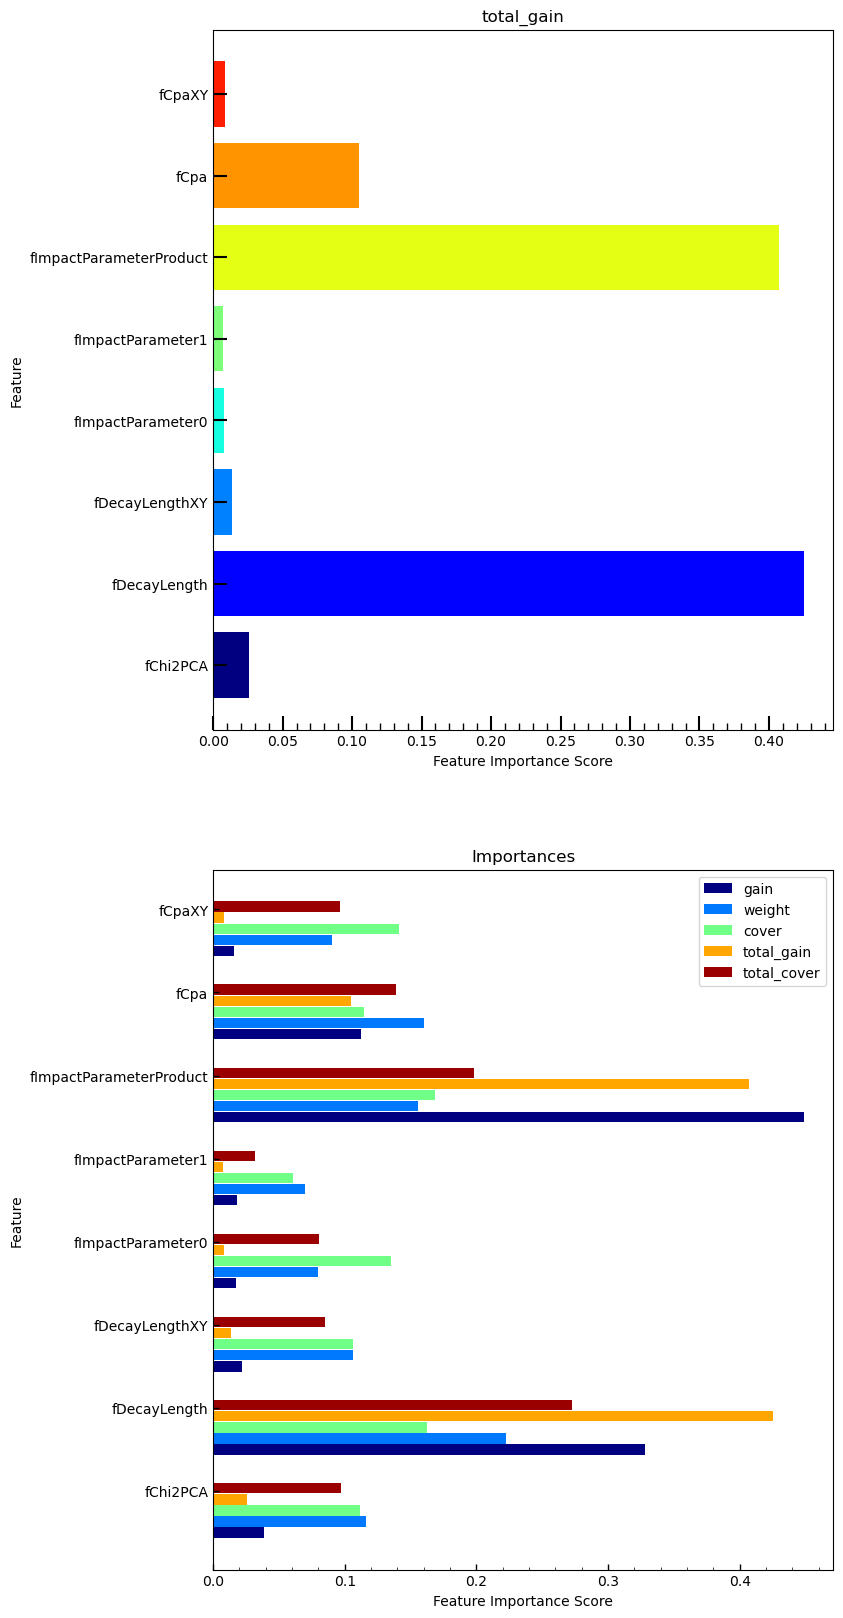

 98%|===================| 78058/79257 [00:48<00:00]        

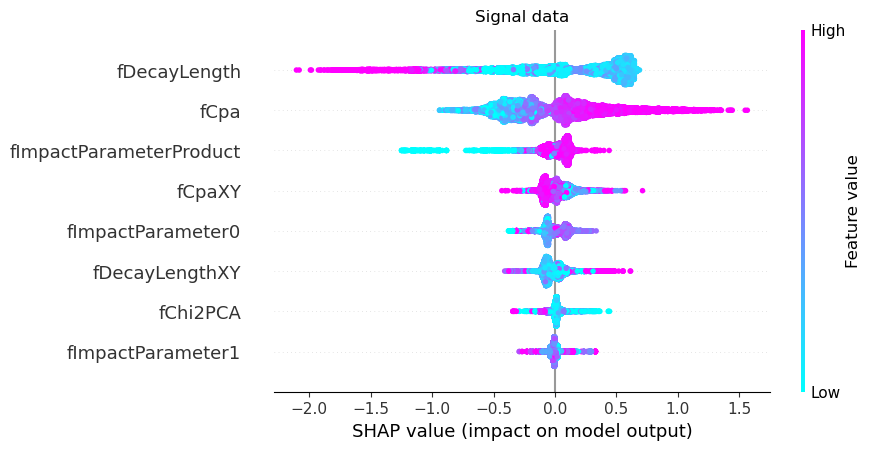

Micro-averaged One-vs-Rest ROC AUC score:
0.879
Macro-averaged One-vs-Rest ROC AUC score:
0.867


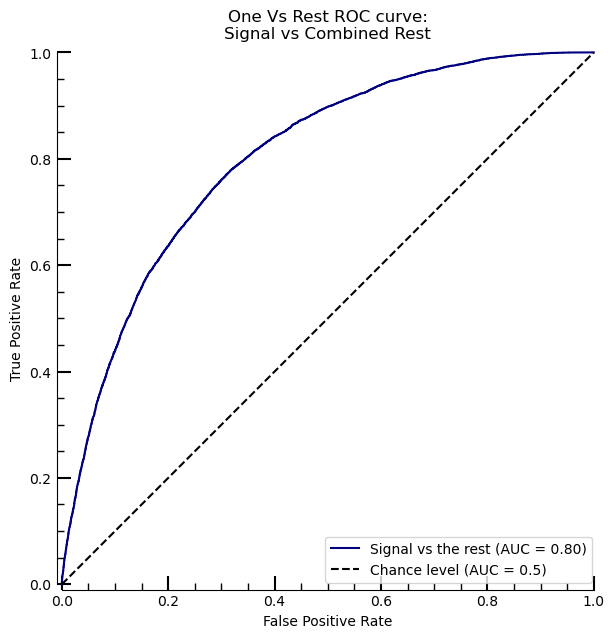

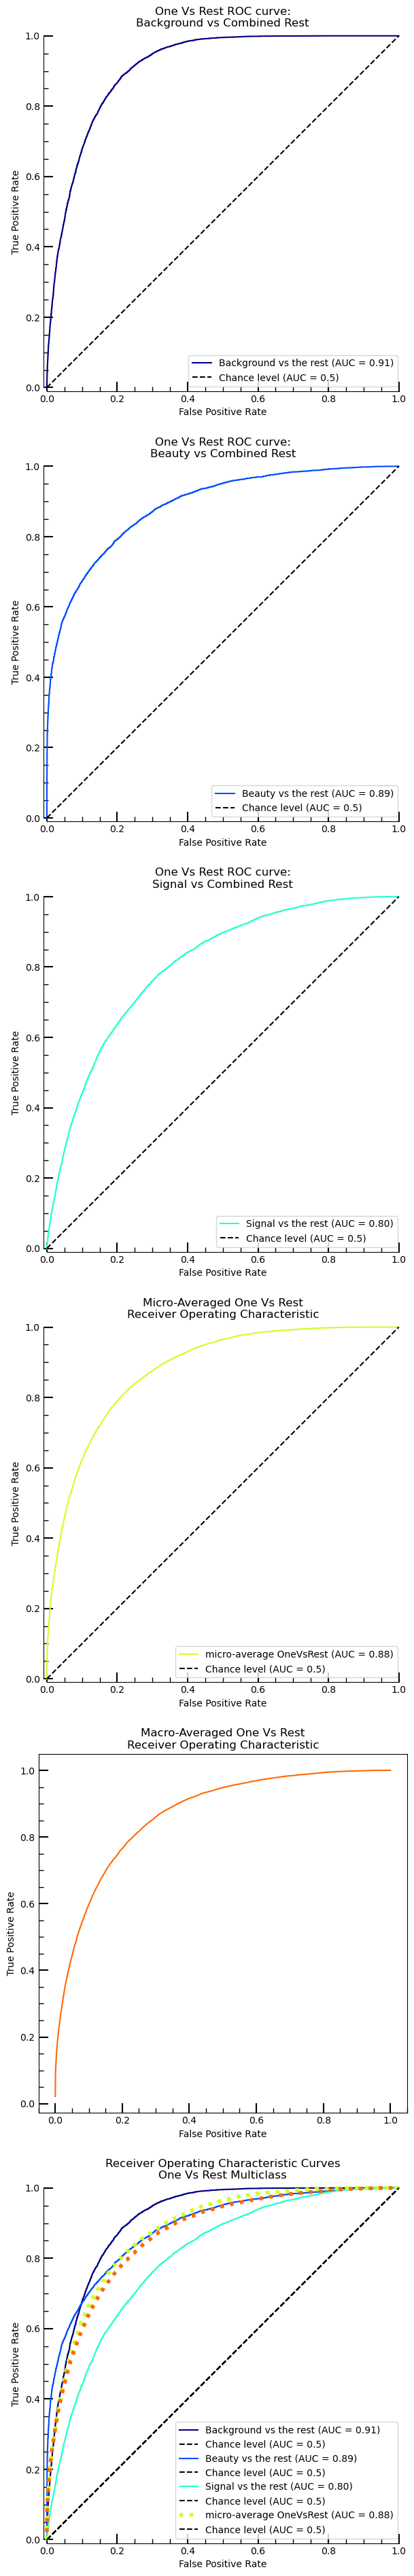

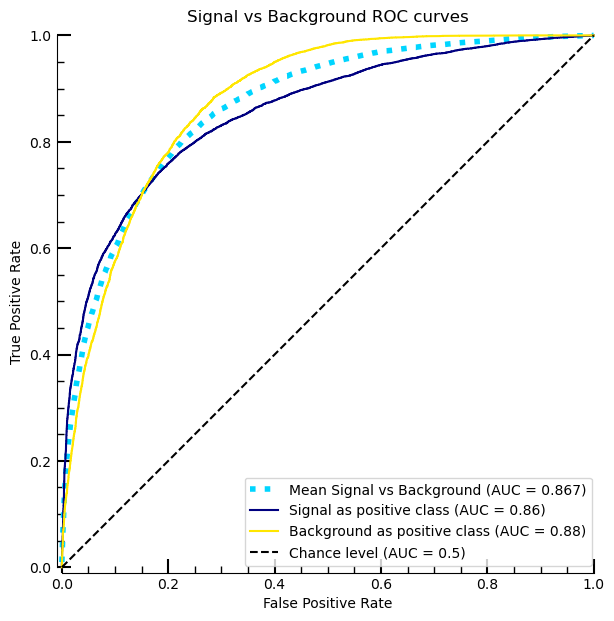

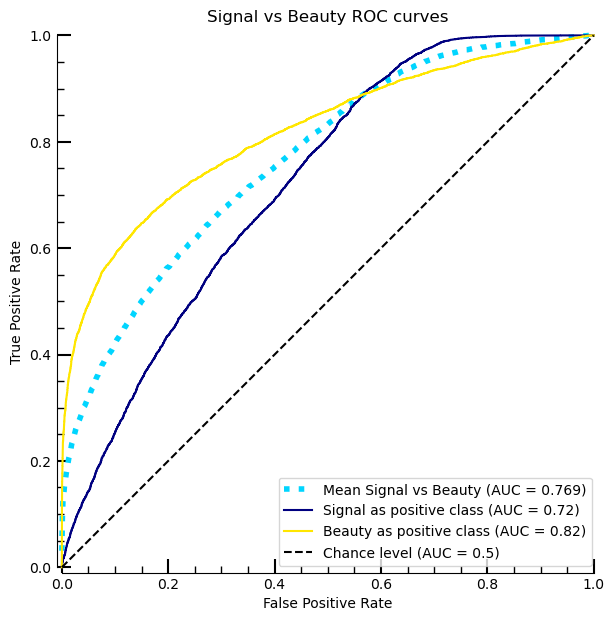

In [30]:
model, matrix = complete_train( X_0, Y_0, Final_test, train_col, train_lab, main = 'Signal', noise = True )

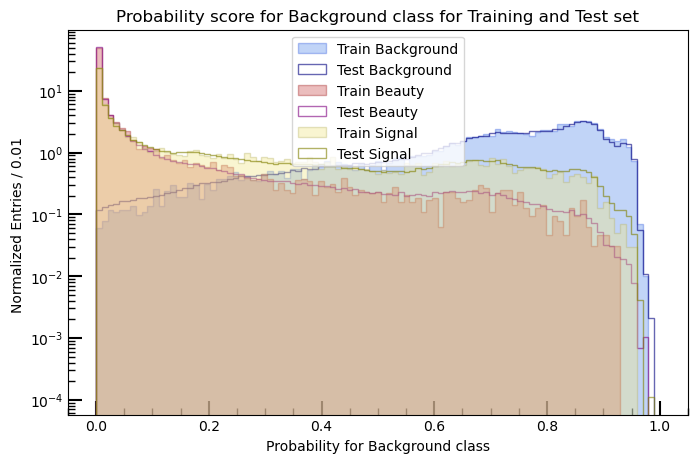

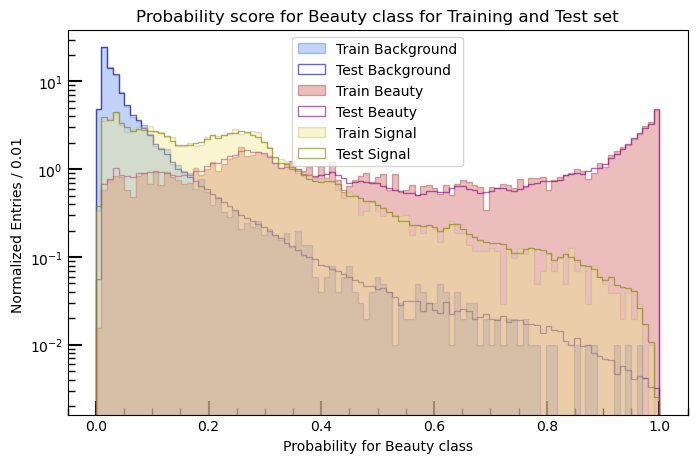

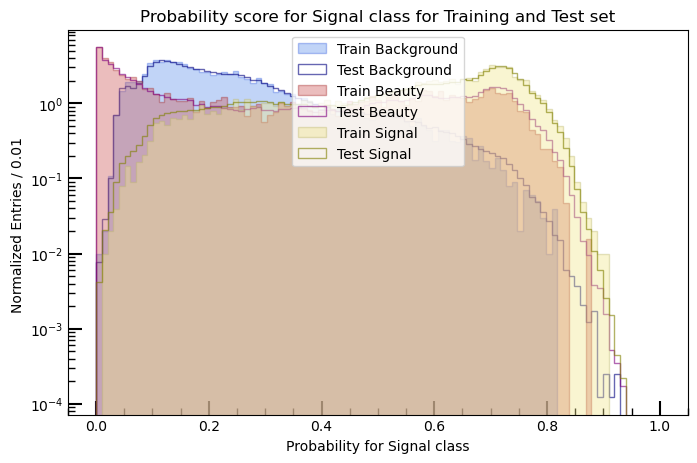

In [31]:
final_classifier( model, X_0, Y_0, Final_test, train_col, labels = train_lab, Y_key = 'fLabel' )

In [32]:
matrix

### Results showing

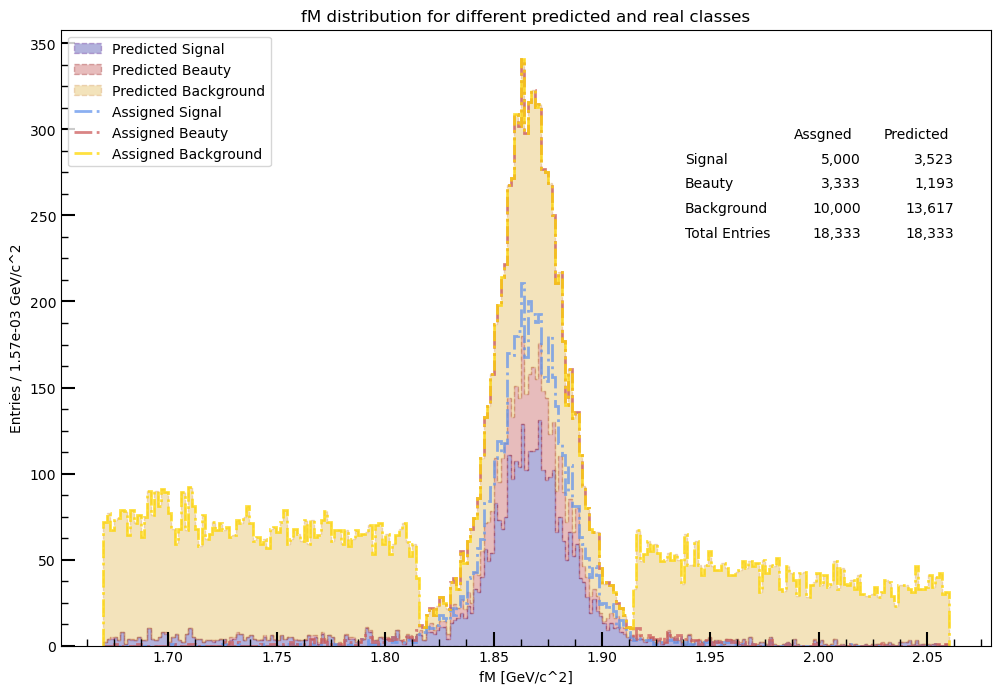

In [33]:
decision_cuts = { 'Background' : 0.65, 'Signal' : 0.6 , 'Beauty' : 0.8 }
# cutted_df = test_df( df = Final_test, labels = train_lab, pt_int = pt_range[cut_index],  signal_size = { 'Signal' : 5e+3, 'Beauty' : 2e+3, 'Background' : 2e+4 }, Y_key = 'fLabel' )
cutted_df = test_df( df = Final_test, labels = train_lab, pt_int = pt_range[cut_index],  signal_size = { 'Signal' : signal_points/4, 'Beauty' : signal_points/6, 'Background' : signal_points/2 }, Y_key = 'fLabel' )

distribution_histo( cutted_df, model, train_col, train_lab, decision_cuts, key = 'fM', Y_key = 'fLabel', units = 'GeV/c^2' ) 

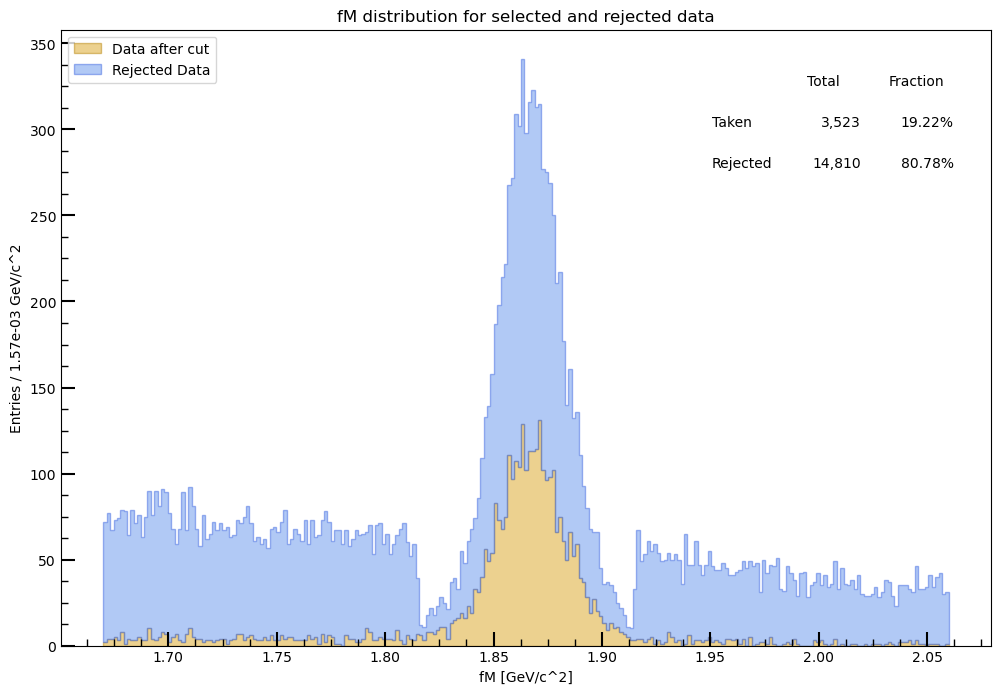

In [34]:
cut_show( cutted_df, model, train_col, train_lab, decision_cuts, key = 'fM', units = 'GeV/c^2' ) 

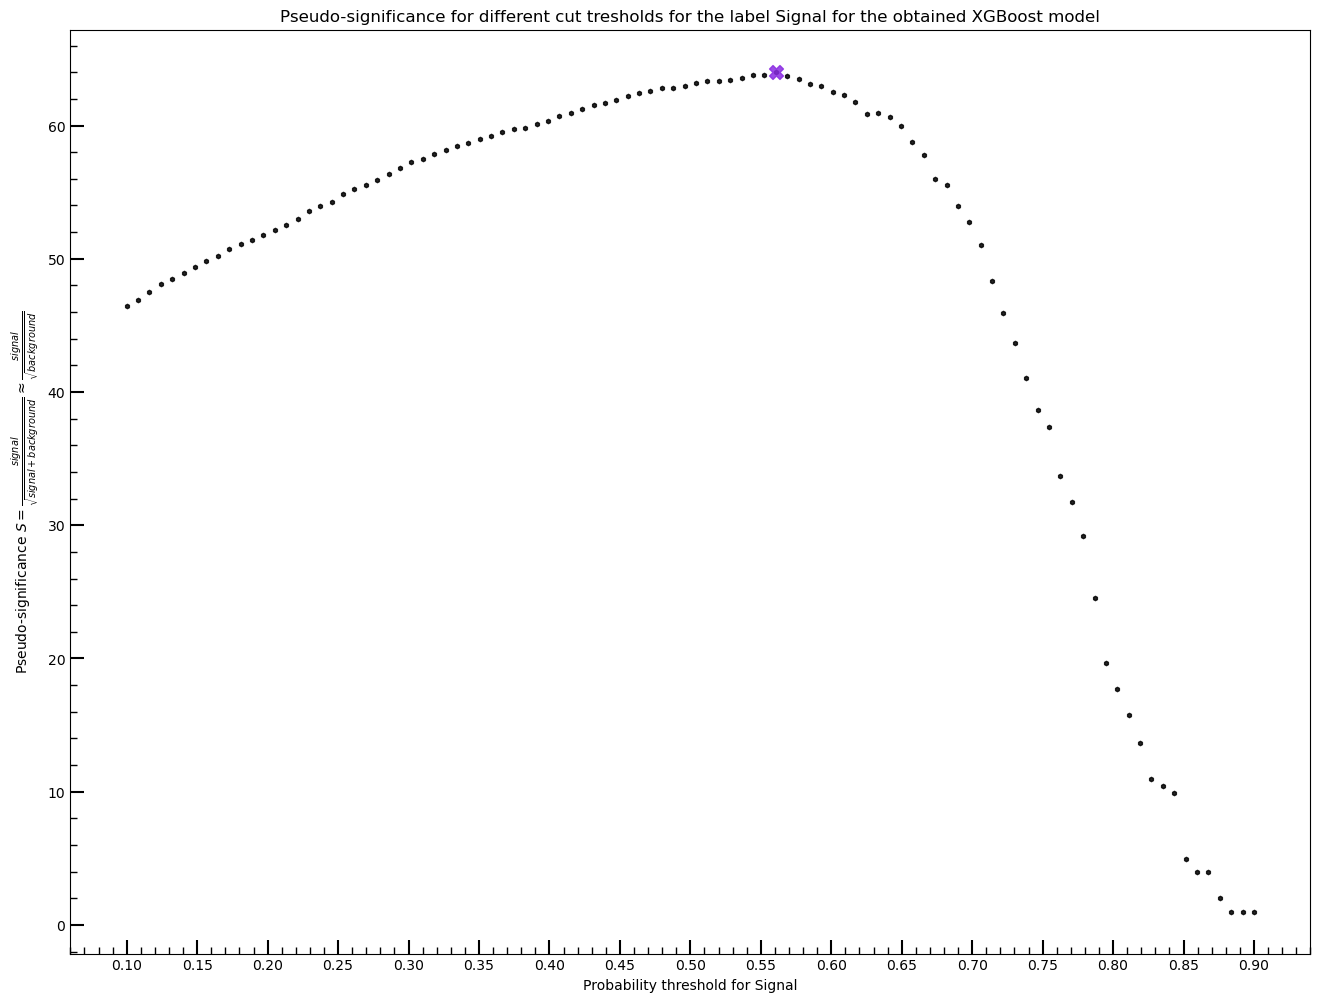

In [35]:
 _ = cut_search( model, cutted_df, train_col, cuts = {}, cut_label = 'Signal', labels = train_lab, min_p = 0.1, max_p = 0.9, steps = 100, Y_key = 'fLabel' )

### Sub pt range search for cuts

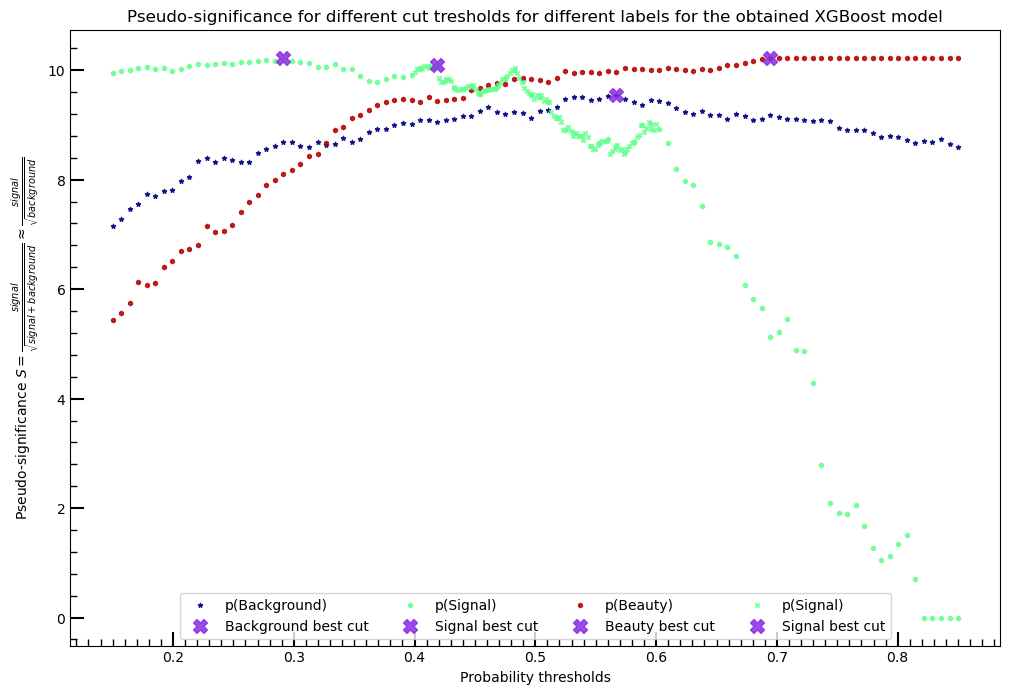

Background cut:   0.567 
Signal cut:   0.418 
Beauty cut:   0.694 


In [36]:
secondary_cut = 0
used_pt = sub_pt_range[ cut_index ][ secondary_cut ]

label_cs = { 'Beauty', 'Signal', 'Background' }

df_composition = { 'Signal' : signal_points/50, 'Beauty' : signal_points/50, 'Background' : signal_points/10 }

cut_dic = sequential_cut_search( model, Final_test, train_col = train_col, pt_int = used_pt, cut_labels = label_cs, labels = train_lab, signal_size = df_composition, Y_key = 'fLabel' )

# sub_df = test_df( df = Final_test, labels = train_lab, pt_int =used_pt,  signal_size = { 'Signal' : 1e+3, 'Beauty' : 0.5e+3, 'Background' : 2e+3 }, Y_key = 'fLabel' )
# cut_dic = {}

#### Beauty cut

In [37]:
# beauty_cut = cut_search( model, cutted_df, train_col, cuts = cut_dic, cut_label = 'Beauty', labels = train_lab, min_p = 0.1, max_p = 0.9, steps = 100, Y_key = 'fLabel' )
# cut_dic[ 'Beauty' ] = beauty_cut[ 0 ]
# print( f"Max pseduo-significance: {beauty_cut[1]:.1f}")

#### Signal cut

In [38]:
# signal_cut = cut_search( model, cutted_df, train_col, cuts = cut_dic, cut_label = 'Signal', labels = train_lab, min_p = 0.1, max_p = 0.9, steps = 100, Y_key = 'fLabel' )
# cut_dic[ 'Signal' ] = signal_cut[ 0 ]
# print( f"Max pseduo-significance: {signal_cut[1]:.1f}")

#### Backgrund cut

In [39]:
# background_cut = cut_search( model, cutted_df, train_col, cuts = cut_dic, cut_label = 'Background', labels = train_lab, min_p = 0.1, max_p = 0.9, steps = 100, Y_key = 'fLabel' )
# cut_dic[ 'Background' ] = background_cut[ 0 ]
# print( f"Max pseduo-significance: {background_cut[1]:.1f}")

In [40]:
# signal_cut = cut_search( model, cutted_df, train_col, cuts = cut_dic, cut_label = 'Signal', labels = train_lab, min_p = 0.4, max_p = 0.6, steps = 50, Y_key = 'fLabel' )
# cut_dic[ 'Signal' ] = signal_cut[ 0 ]
# print( f"Max pseduo-significance: {signal_cut[1]:.1f}")

#### Automatic grid search

100%|█████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 150.26trial/s, best loss: -11.019085858843145]
Background cut:   0.421 
Beauty cut:   0.792 
Signal cut:   0.434 


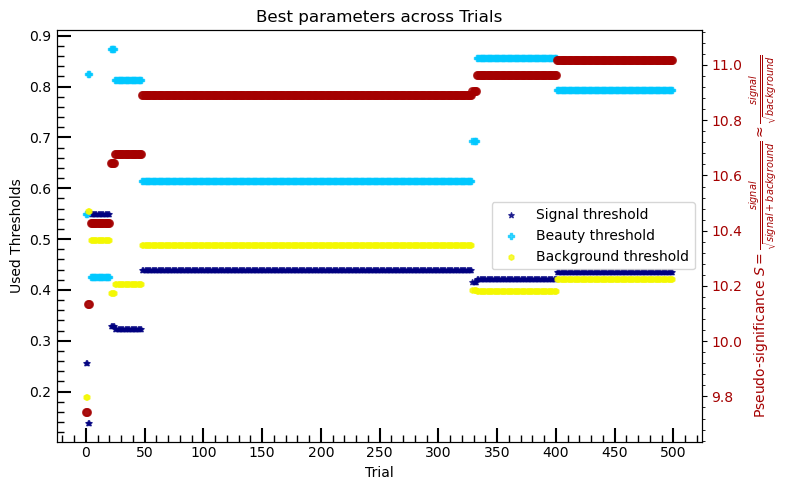

In [41]:
# starting the class
cutter = auto_cut_search( model, Final_test, train_col = train_col, pt_int = used_pt, cut_labels = label_cs, labels = train_lab, 
                          par_space = { 'Signal' : ( 0.1, 0.9 ), 'Beauty' : ( 0.1, 0.9 ), 'Background' : ( 0.1, 0.9 ) },
                          signal_size = df_composition, Y_key = 'fLabel' )
cut_dic = cutter.search( max_eval = 500 )
cutter.plot_progress( 'best' )


#### All Interval grid search

100%|█████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 147.99trial/s, best loss: -10.900039687595035]
Background cut:   0.457 
Beauty cut:   0.711 
Signal cut:   0.262 


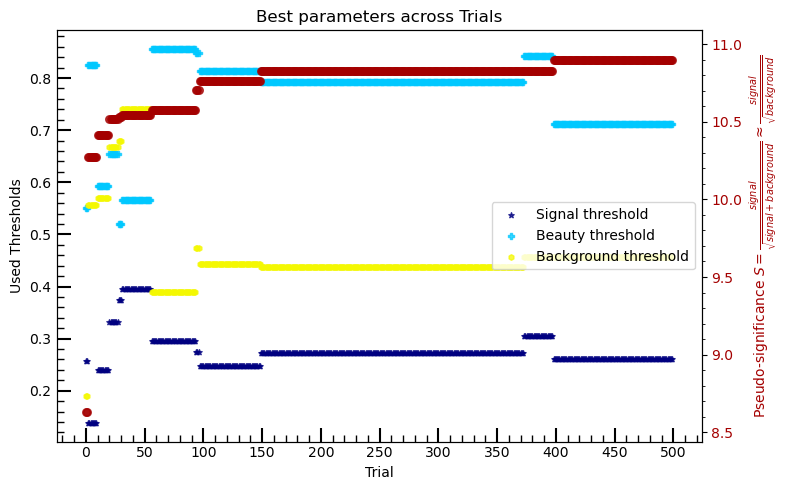

100%|█████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 151.72trial/s, best loss: -12.688783850396941]
Background cut:   0.371 
Beauty cut:   0.671 
Signal cut:   0.352 


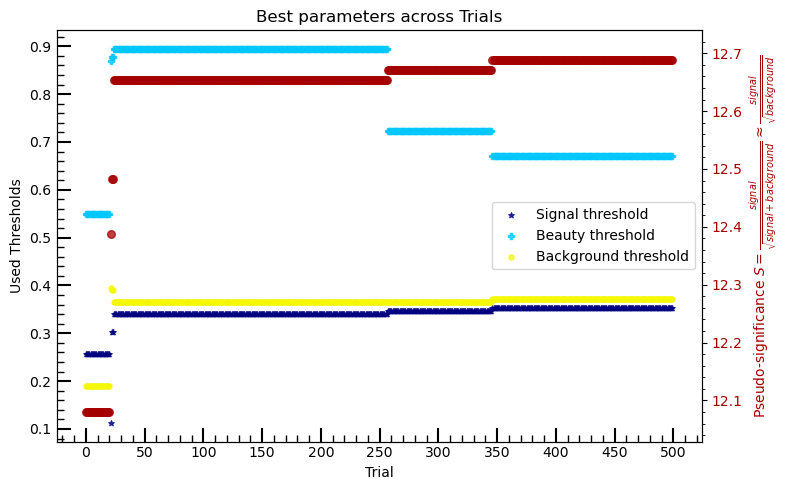

100%|██████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 153.05trial/s, best loss: -13.34187699756604]
Background cut:   0.217 
Beauty cut:   0.448 
Signal cut:   0.552 


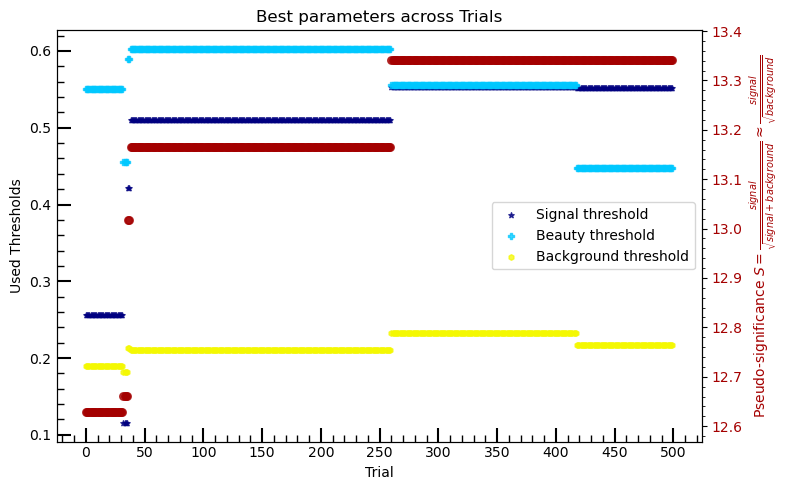

100%|██████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 151.03trial/s, best loss: -16.57034312216982]
Background cut:   0.116 
Beauty cut:   0.465 
Signal cut:   0.526 


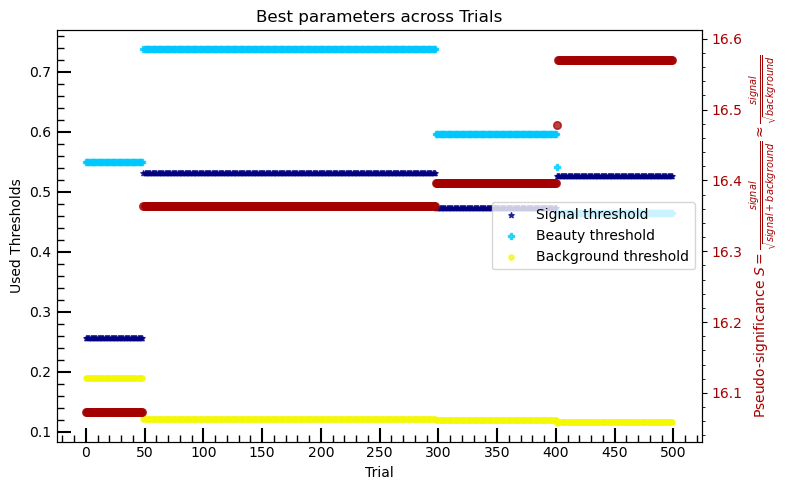

100%|█████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 145.66trial/s, best loss: -15.042507338440192]
Background cut:   0.118 
Beauty cut:   0.866 
Signal cut:   0.473 


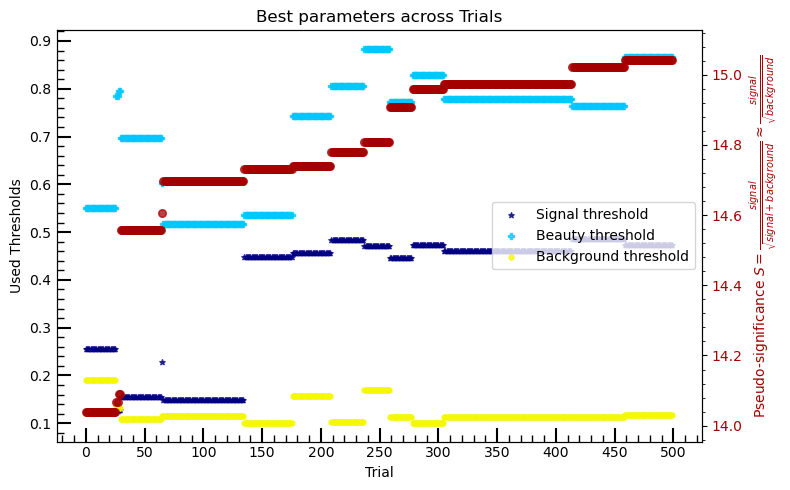

100%|█████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 152.00trial/s, best loss: -16.205898541610818]
Background cut:   0.101 
Beauty cut:   0.437 
Signal cut:   0.136 


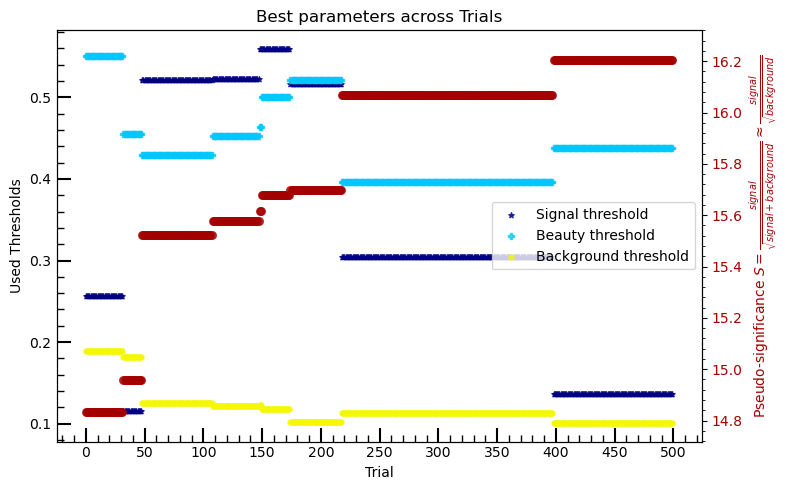

In [42]:
results = { 'Index' : [], 'Interval' : [], 'Background cut' : [], 'Beauty cut': [], 'Signal cut': [], 'Efficiency' : [], 'Beauty Efficiency' : [] }
for i, sub_pt in enumerate(sub_pt_range[ cut_index ]) :
    cutter = auto_cut_search( model, Final_test, train_col = train_col, pt_int = sub_pt, cut_labels = label_cs, labels = train_lab, 
                              par_space = { 'Signal' : ( 0.1, 0.9 ), 'Beauty' : ( 0.1, 0.9 ), 'Background' : ( 0.1, 0.9 ) },
                              signal_size = df_composition, Y_key = 'fLabel' )
    cut_dic = cutter.search( max_eval = 500 )
    cutter.plot_progress( 'best' )
    results['Index'].append( i )
    results['Interval'].append( sub_pt )
    results['Background cut'].append( cut_dic[ 'Background' ] )
    results['Beauty cut'].append( cut_dic[ 'Beauty' ] )
    results['Signal cut'].append( cut_dic[ 'Signal' ] )


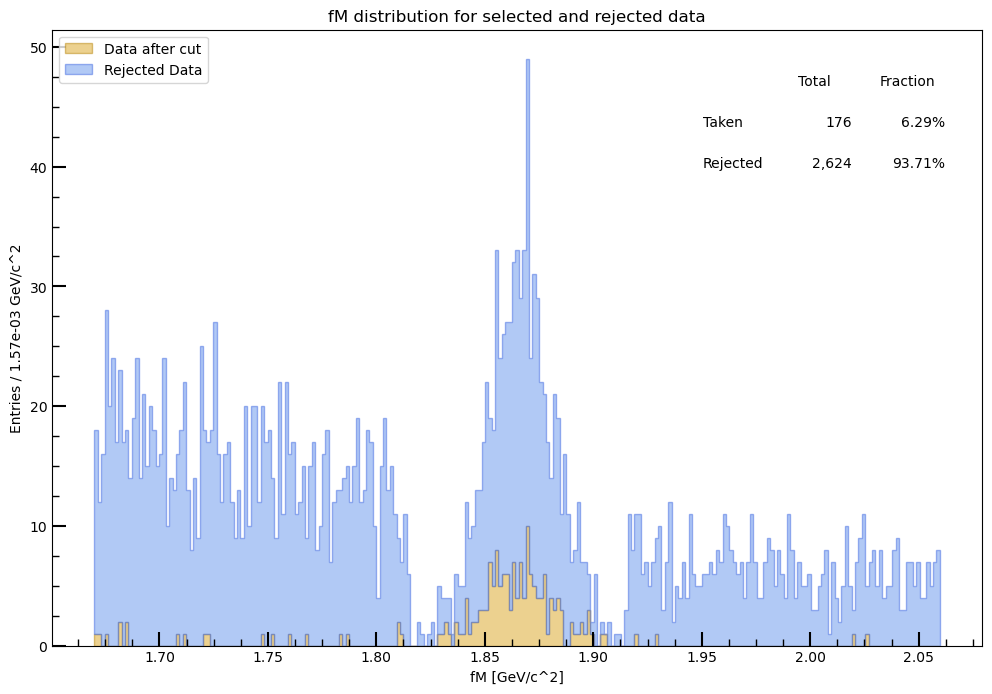

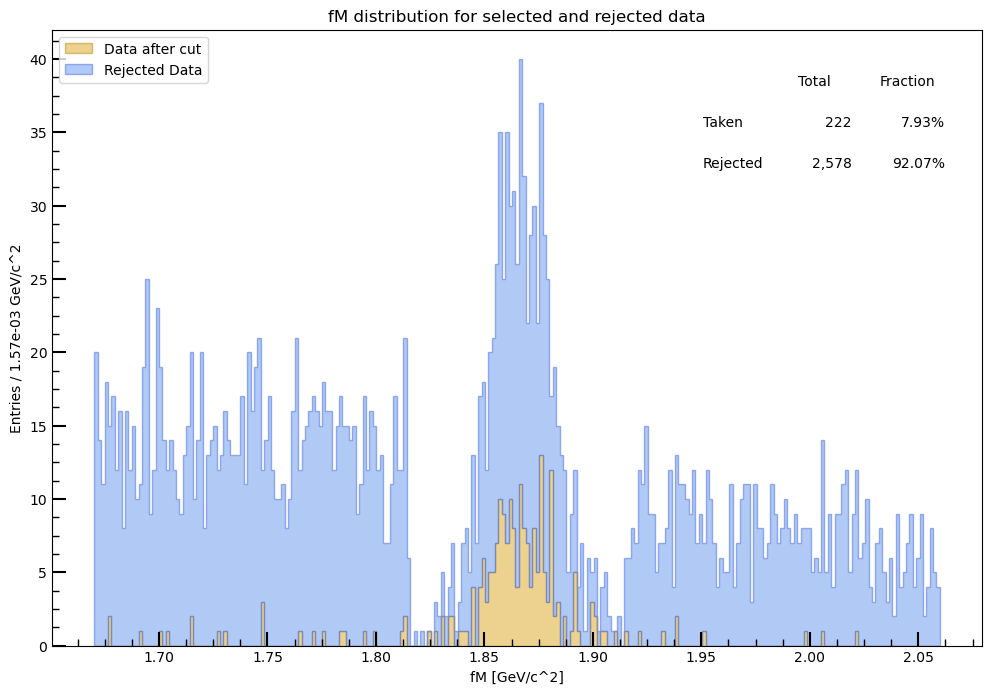

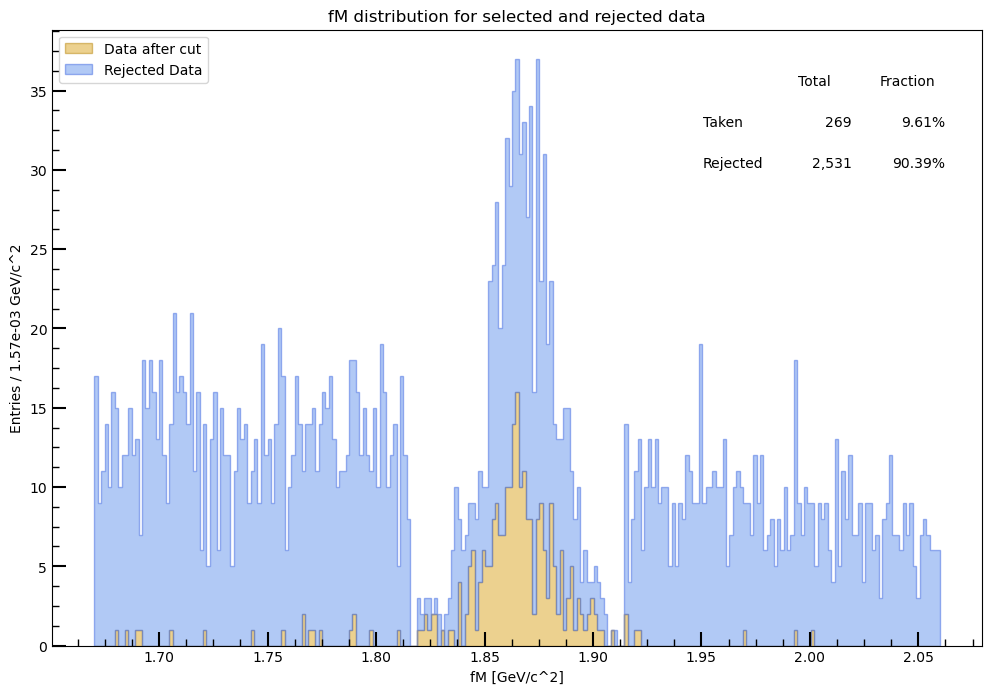

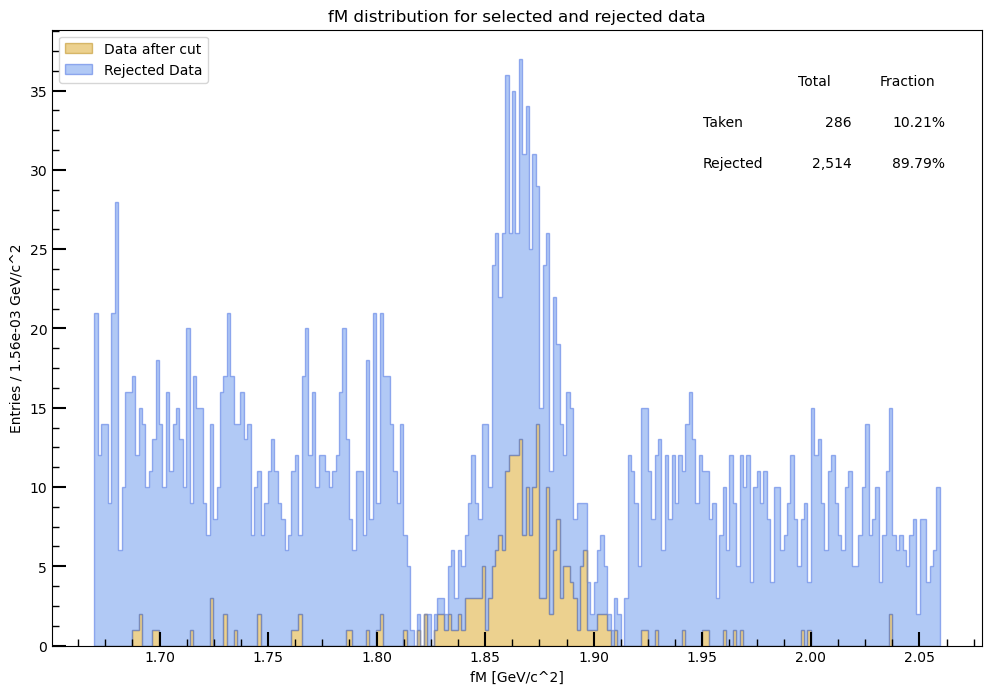

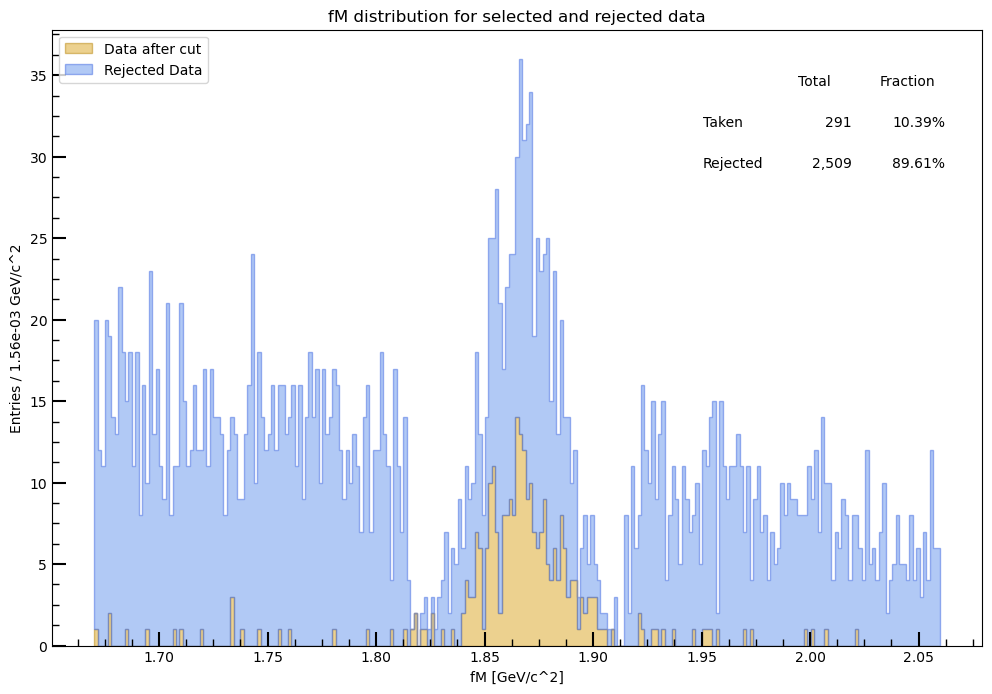

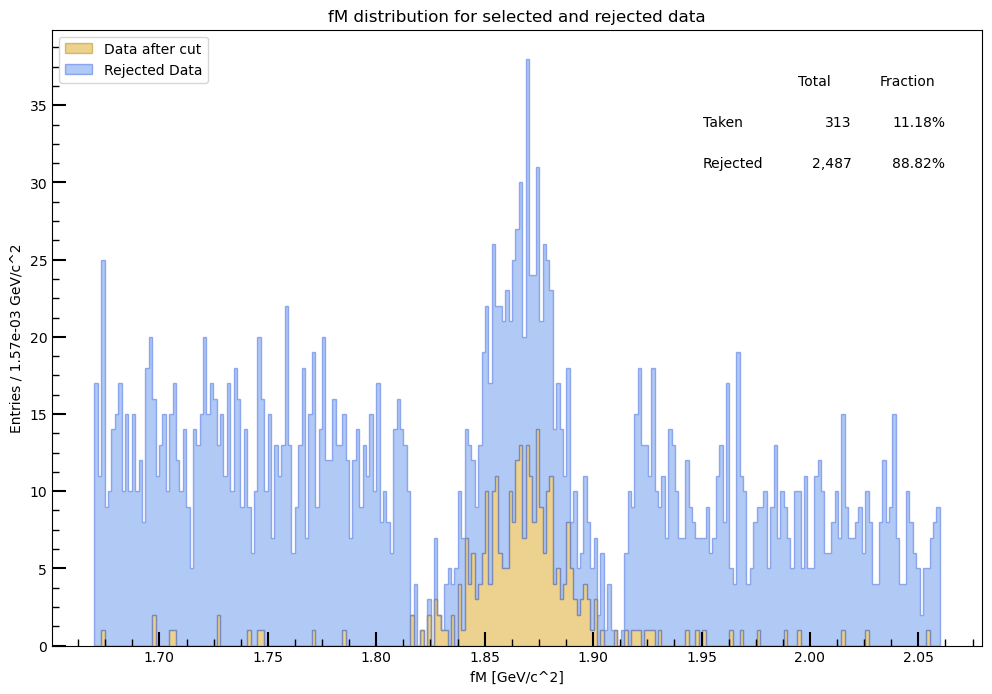

In [43]:
for sub_pt in sub_pt_range[ cut_index ] :
    sub_df = test_df( df = Final_test, labels = train_lab, pt_int =sub_pt,  signal_size = df_composition, Y_key = 'fLabel' )
    decision_cuts = { 'Background' : results['Background cut'][i], 'Signal' : results['Signal cut'][i] , 'Beauty' : results['Beauty cut'][i] }
    
    cut_show( sub_df, model, train_col, train_lab, decision_cuts, key = 'fM', units = 'GeV/c^2' ) 
# for l in cut_dic :
#     print( f"{l} cut:   {cut_dic[l]:.3f} " )

Selected candidates in the remaining Datafile: 30,268 over 201,436 particles


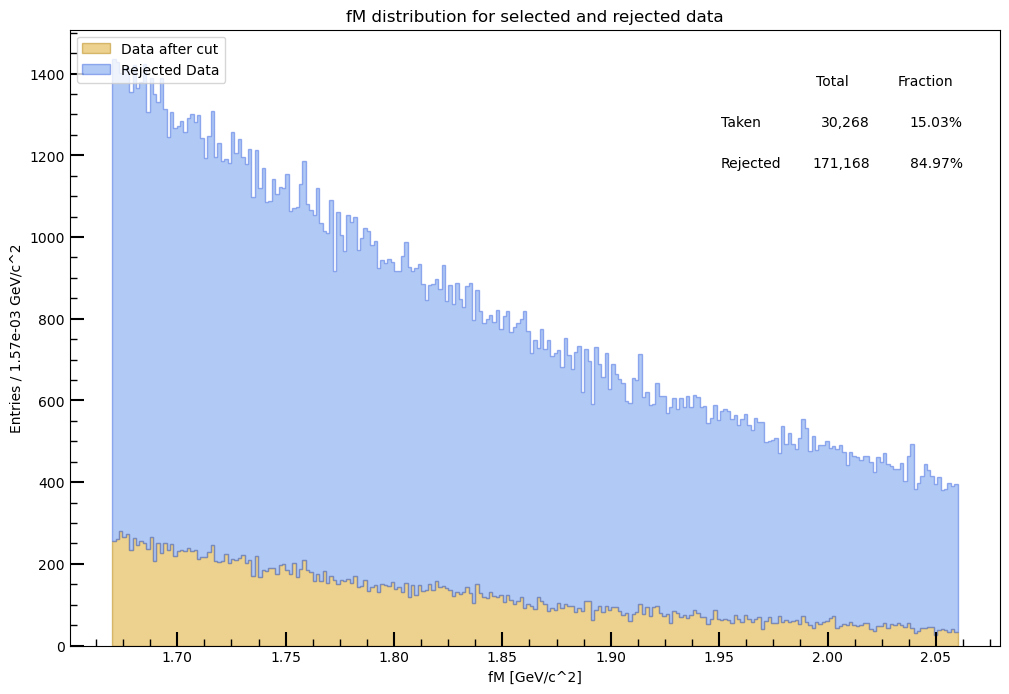

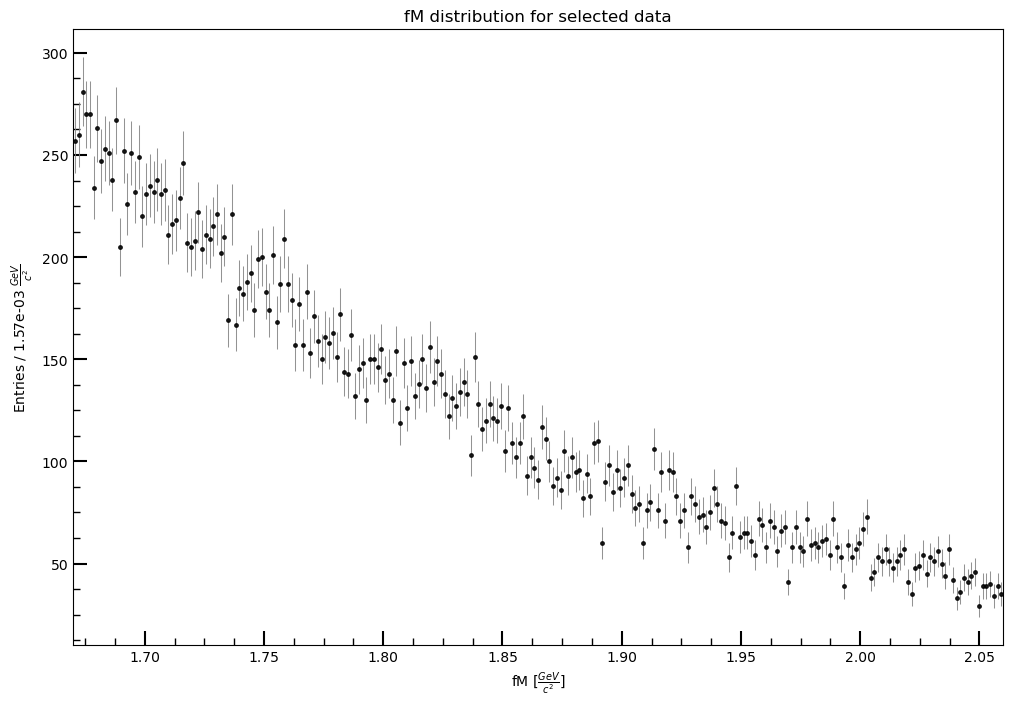

Selected candidates in the remaining Datafile: 21,013 over 197,254 particles


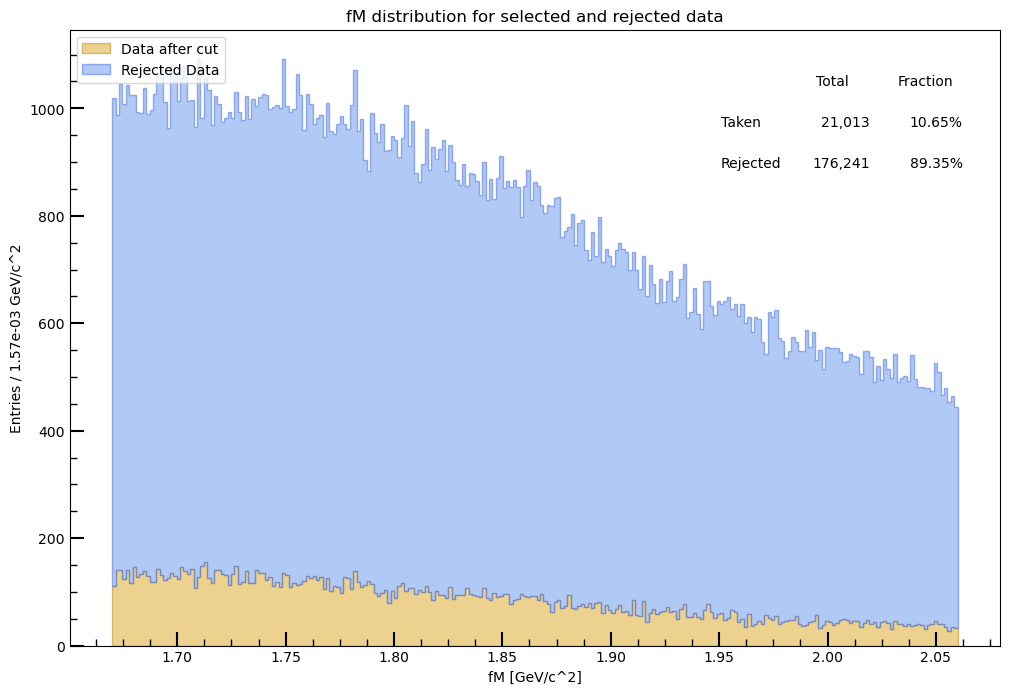

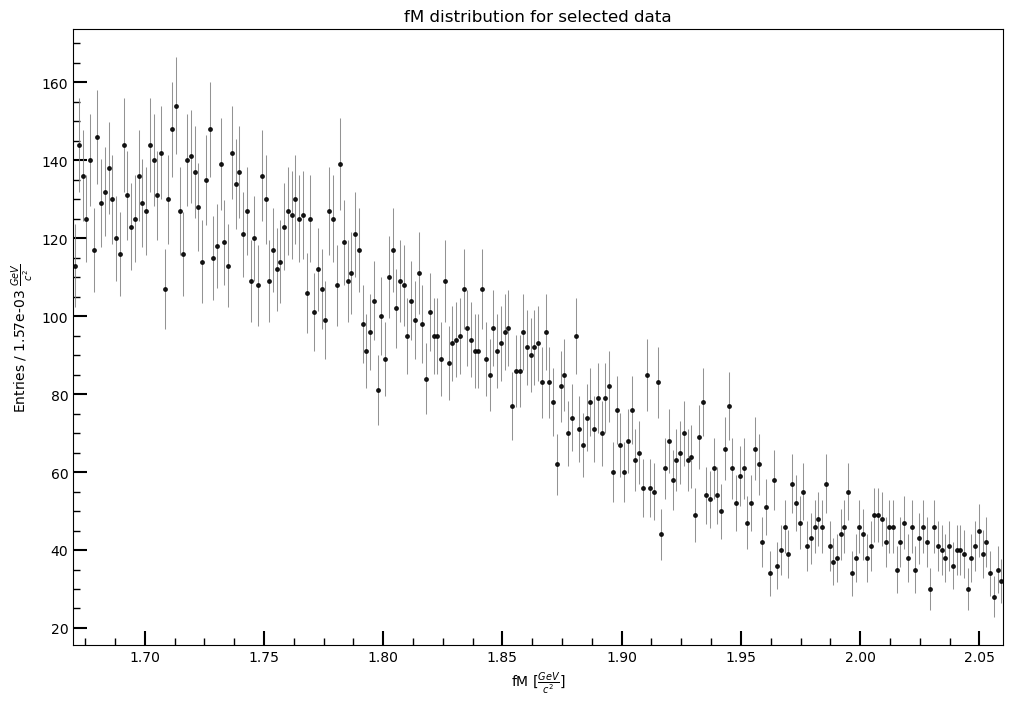

Selected candidates in the remaining Datafile: 6,079 over 175,943 particles


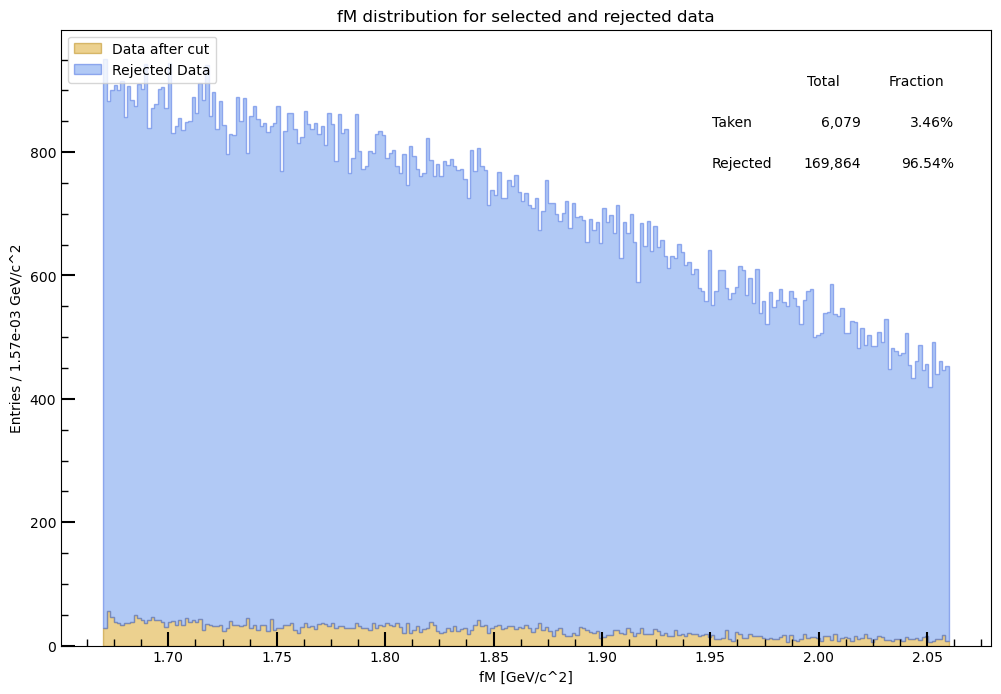

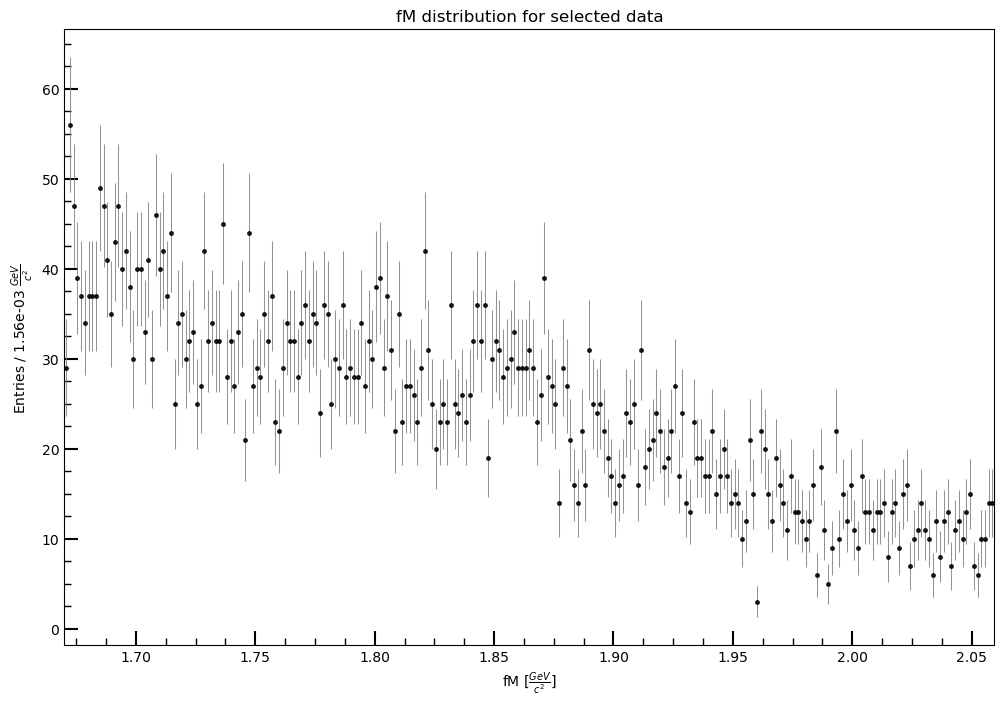

Selected candidates in the remaining Datafile: 2,626 over 176,618 particles


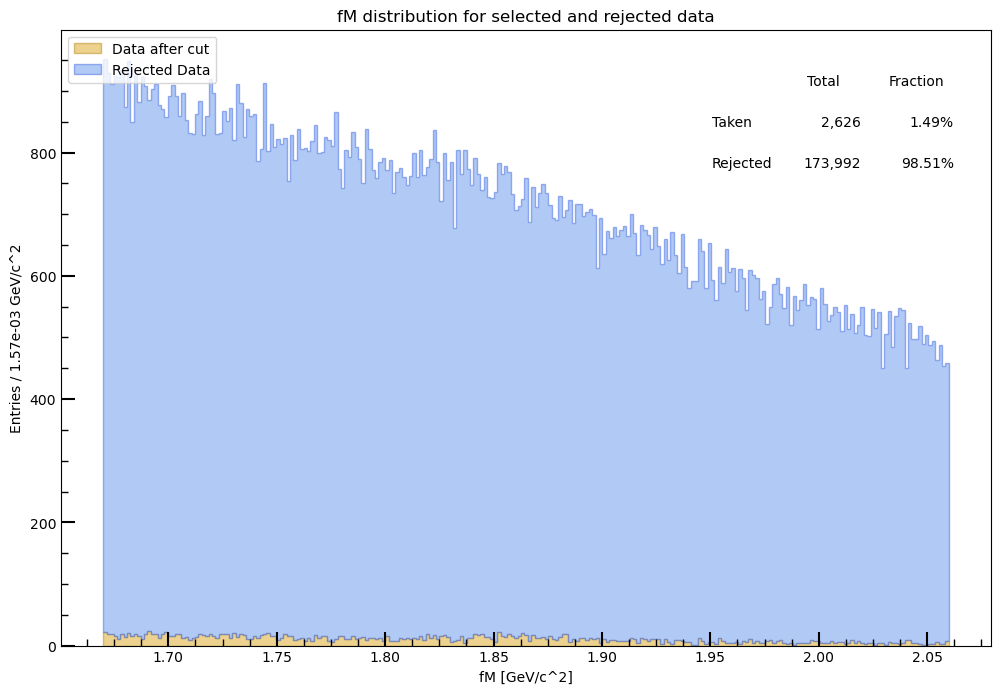

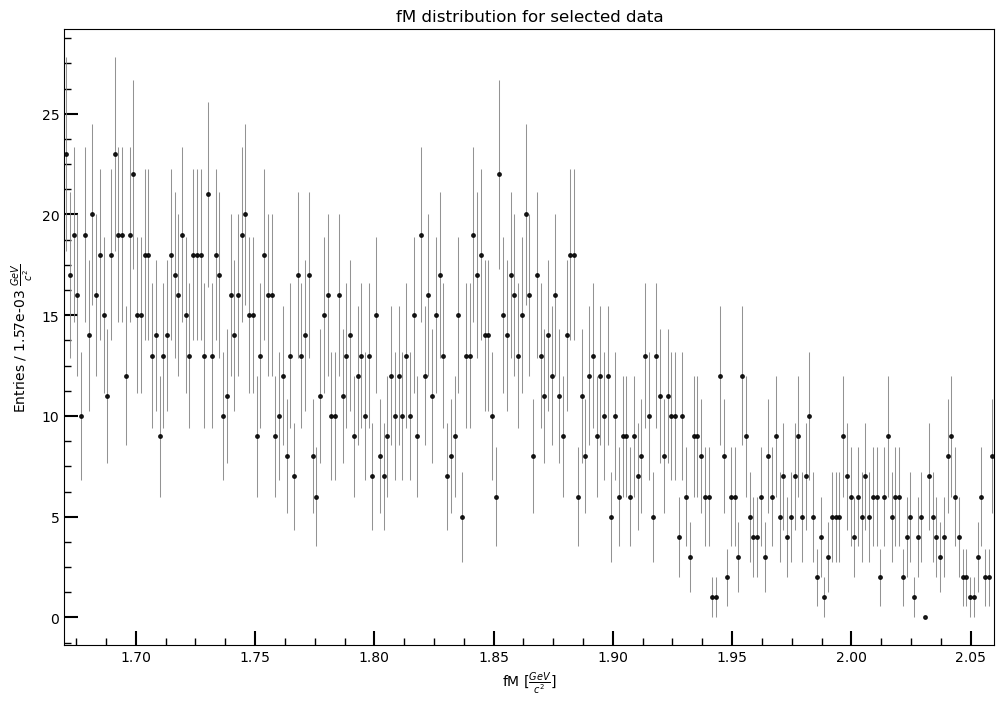

Selected candidates in the remaining Datafile: 2,782 over 173,291 particles


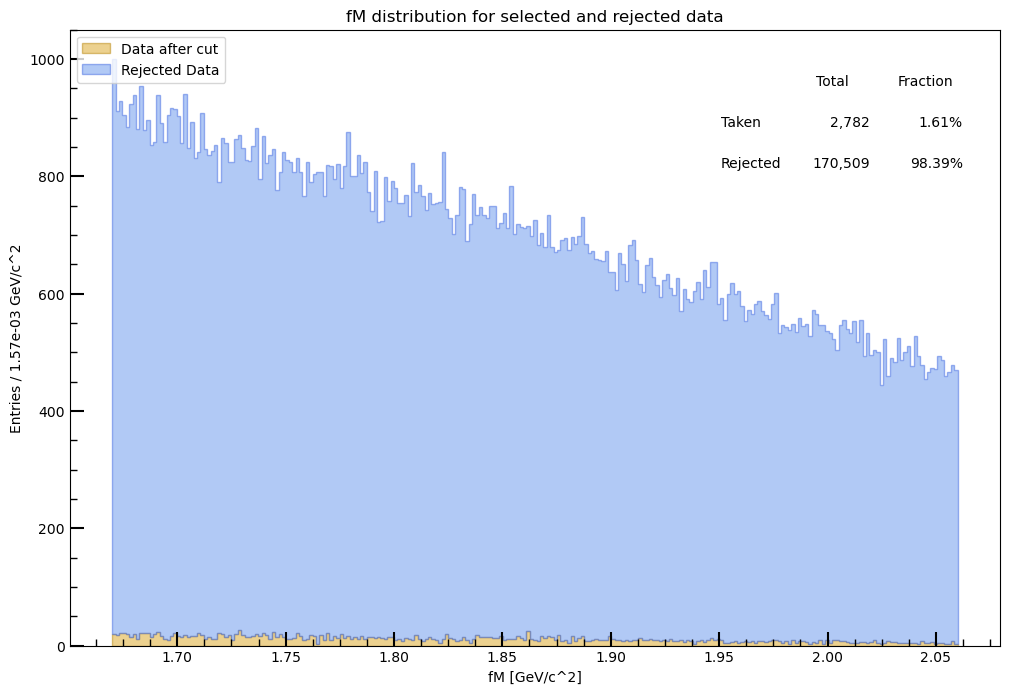

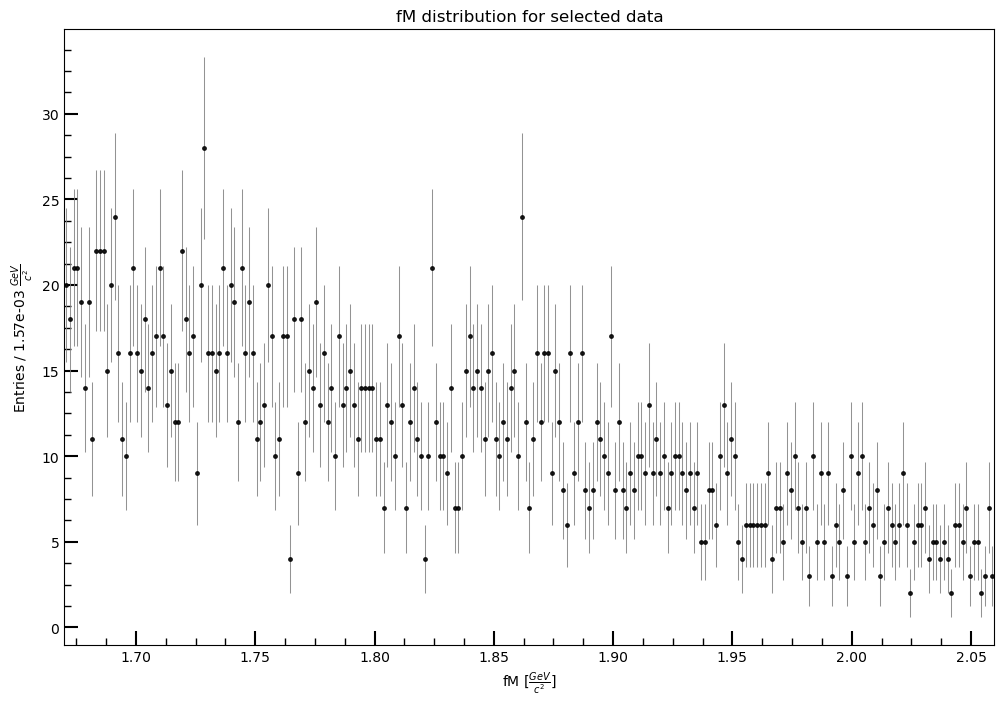

Selected candidates in the remaining Datafile: 2,002 over 158,128 particles


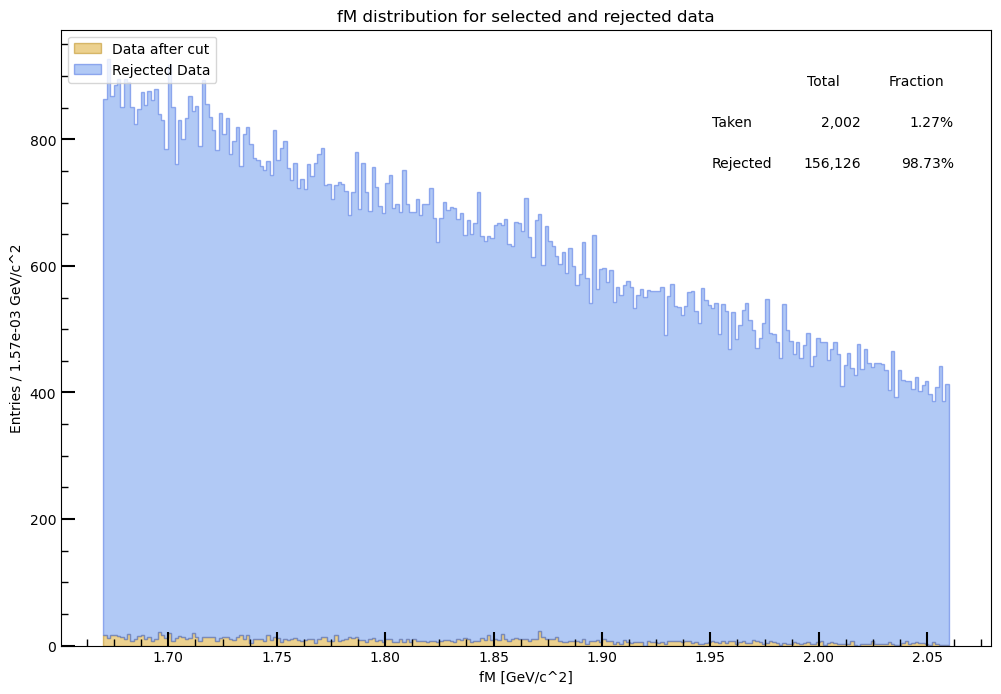

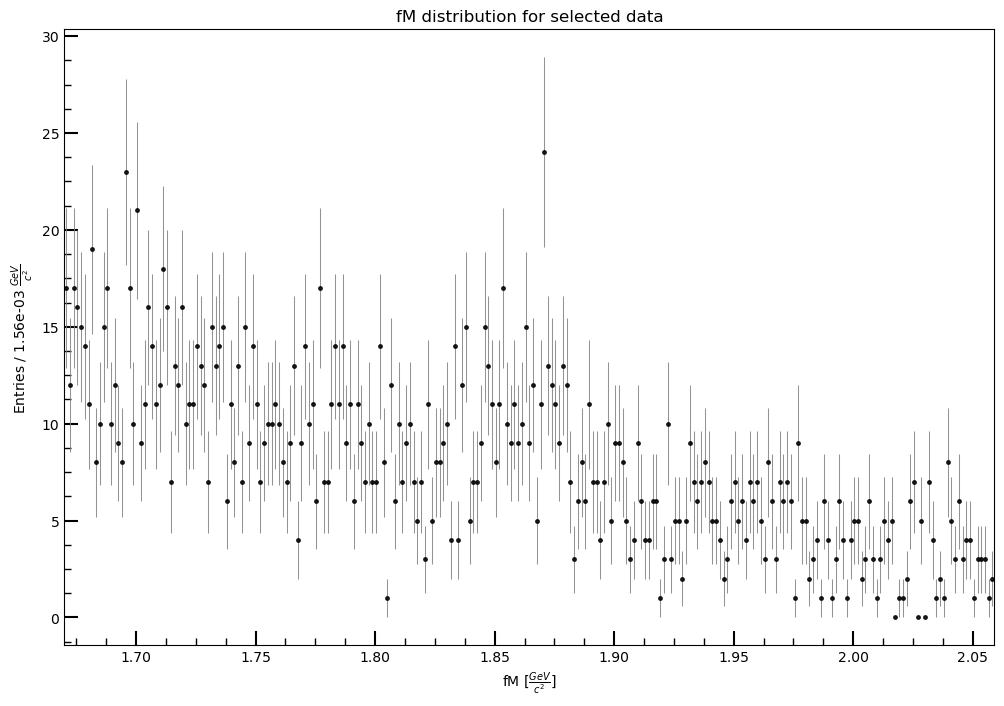

In [44]:
for i, sub_pt in enumerate(sub_pt_range[ cut_index ]) :
    sub_data = Test_0[ Test_0[ 'fPt' ].between( sub_pt[0], sub_pt[1] ) ]
    
    decision_cuts = { 'Background' : results['Background cut'][i], 'Signal' : results['Signal cut'][i] , 'Beauty' : results['Beauty cut'][i] }
    cut_data = xgcut_df( model, sub_data, train_col, train_lab, decision_cuts )
    # cut_data.to_csv( f"Selected_{particle}_Pt_Int_{cut_index}_Sub_Pt_Int_{i}.csv", columns = [ 'fM', 'fPt' ], mode = 'w', header = True, index = False )
    print( f"Selected candidates in the remaining Datafile: { len(cut_data):,} over {len(sub_data):,} particles")
    cut_show( sub_data, model, train_col, train_lab, decision_cuts, key = 'fM', units = 'GeV/c^2' ) 
    root_histo( cut_data, model, train_col, train_lab, decision_cuts, key = 'fM', units = r'$\frac{GeV}{c^2}$' , steps = 250)


Efficiencies computed for the Test MonteCarlo in the Pt interval (0, 0.7):
   - Signal Efficiency: 0.01866
   - Beauty Efficiency: 0.02040
   - Efficiency Fraction (beauty/signal): 1.09322
Efficiencies computed for the Test MonteCarlo in the Pt interval (0.7, 1):
   - Signal Efficiency: 0.03405
   - Beauty Efficiency: 0.02728
   - Efficiency Fraction (beauty/signal): 0.80122
Efficiencies computed for the Test MonteCarlo in the Pt interval (1, 1.25):
   - Signal Efficiency: 0.03104
   - Beauty Efficiency: 0.01890
   - Efficiency Fraction (beauty/signal): 0.60901
Efficiencies computed for the Test MonteCarlo in the Pt interval (1.25, 1.5):
   - Signal Efficiency: 0.03362
   - Beauty Efficiency: 0.02047
   - Efficiency Fraction (beauty/signal): 0.60880
Efficiencies computed for the Test MonteCarlo in the Pt interval (1.5, 1.75):
   - Signal Efficiency: 0.04524
   - Beauty Efficiency: 0.02674
   - Efficiency Fraction (beauty/signal): 0.59117
Efficiencies computed for the Test MonteCarlo in

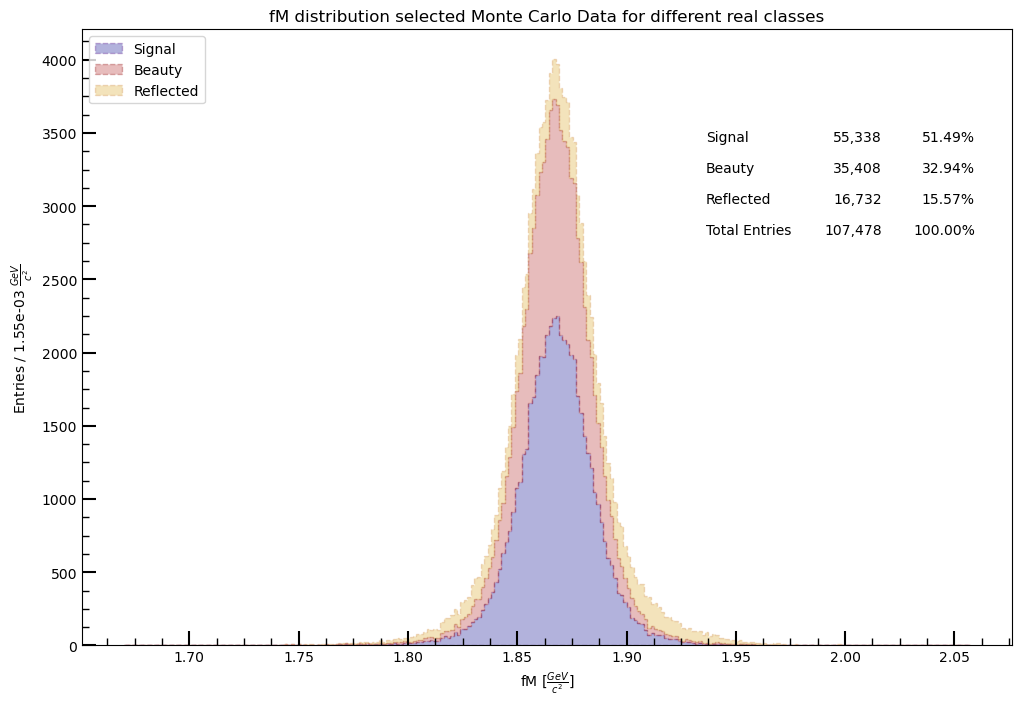

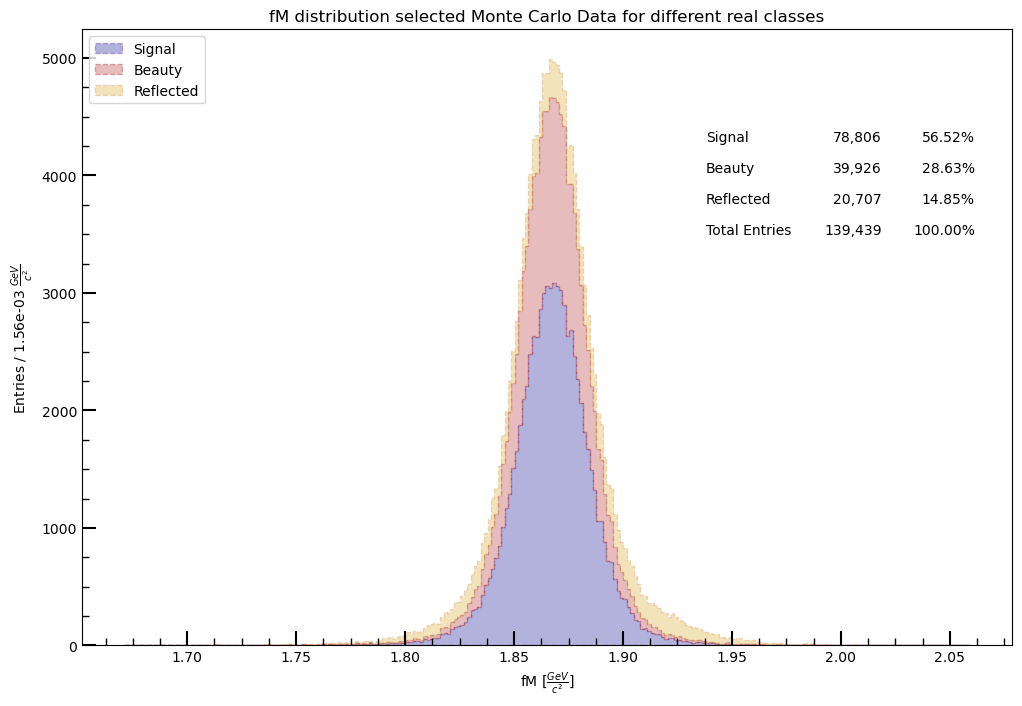

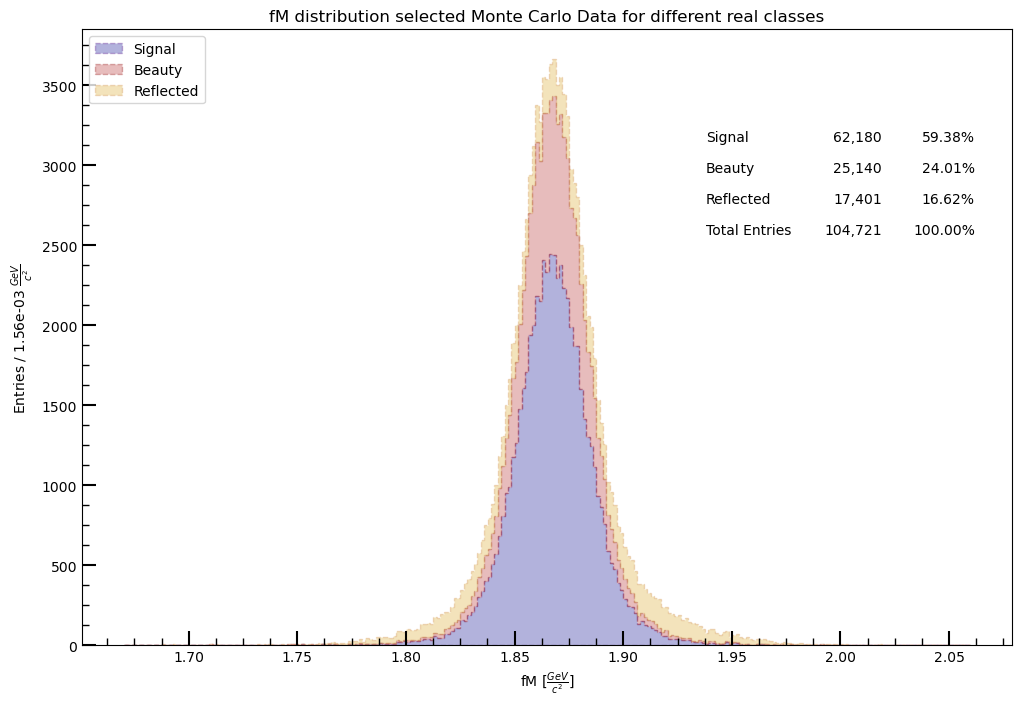

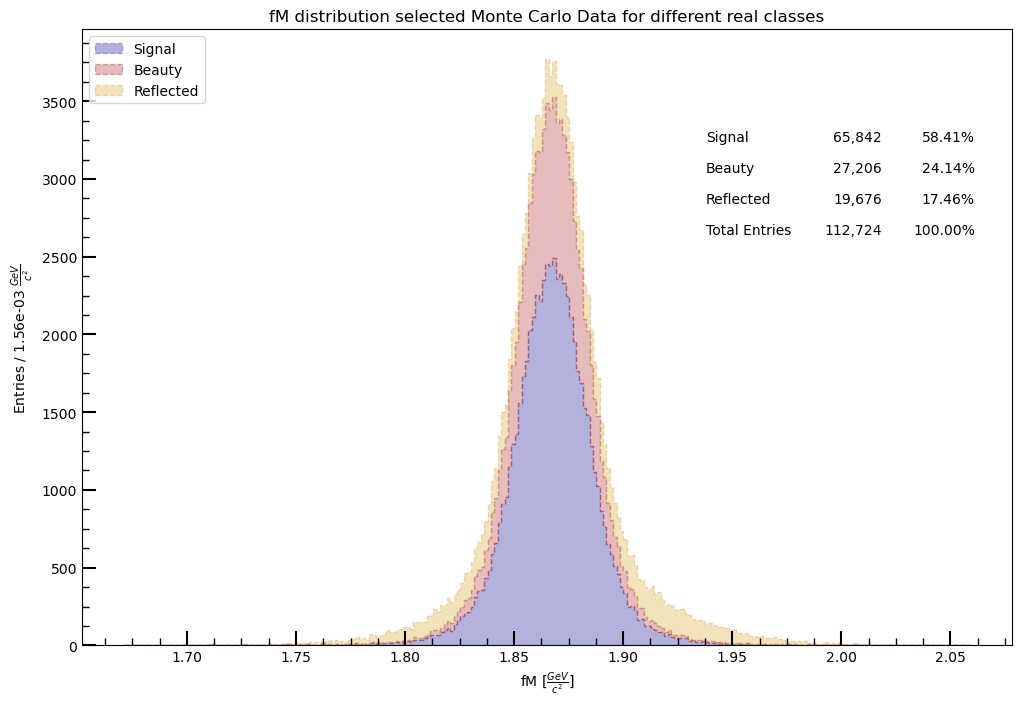

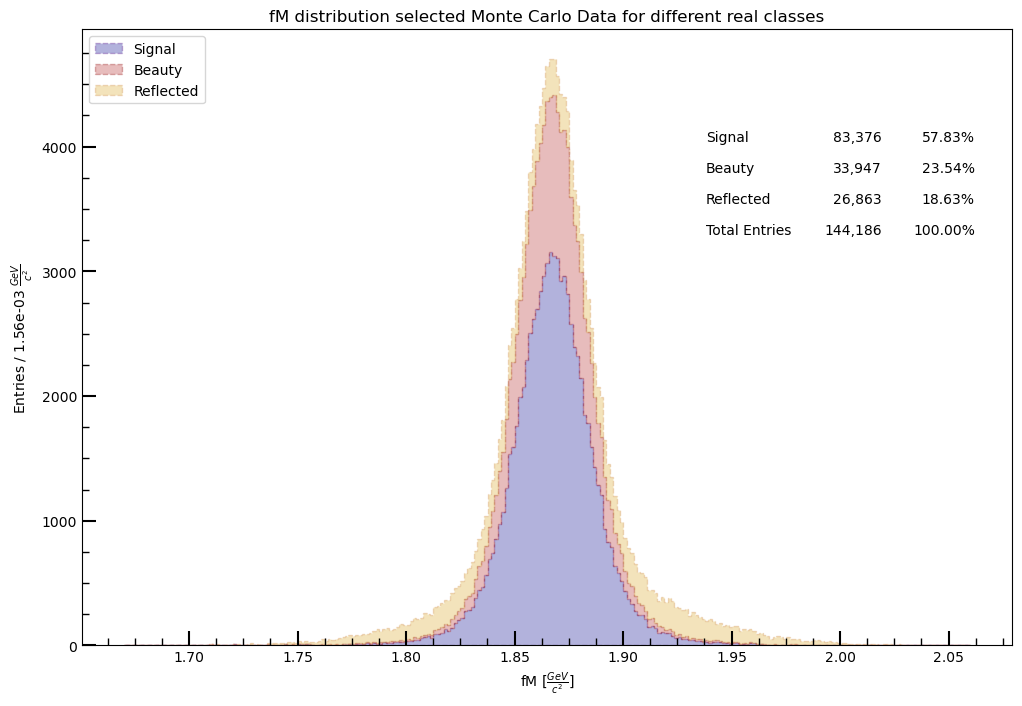

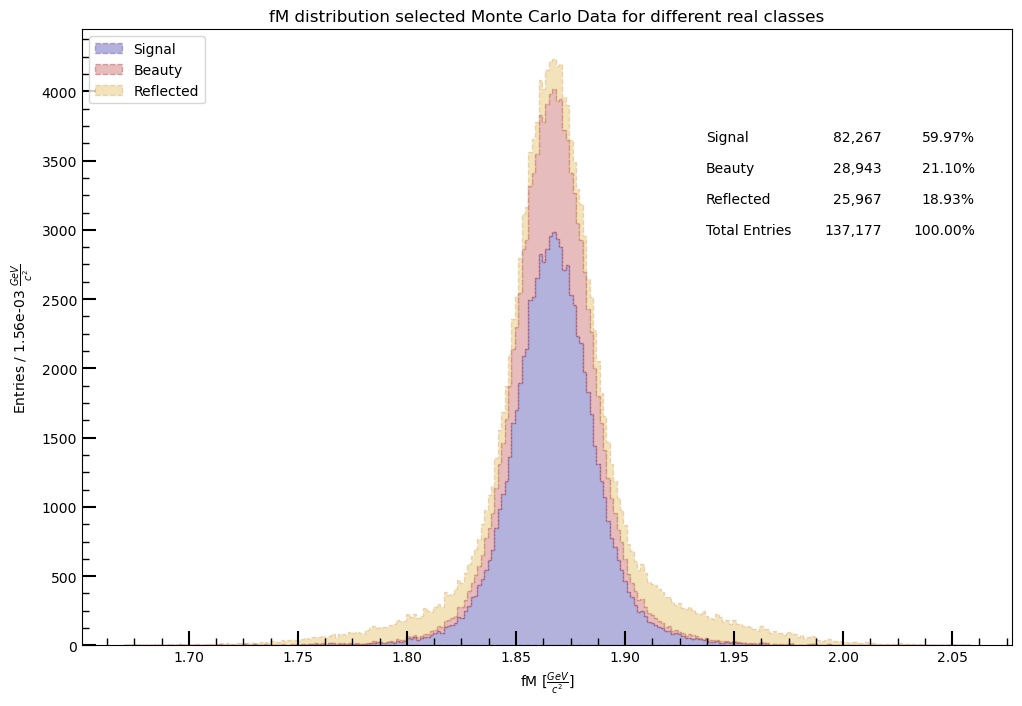

In [45]:
for i, sub_pt in enumerate(sub_pt_range[ cut_index ]) :
    decision_cuts = { 'Background' : results['Background cut'][i], 'Signal' : results['Signal cut'][i] , 'Beauty' : results['Beauty cut'][i] }
    ef, bef = compute_efficiency( model, MC_Test_0, train_col, decision_cuts, signal_fraction, particle = particle, pt_cut =  sub_pt, labels = og_lab,  key = 'fM', Y_key = 'fLabel', units = r'$\frac{GeV}{c^2}$')
    results[ 'Efficiency' ].append(ef)
    results[ 'Beauty Efficiency' ].append(bef)

In [46]:
cut_df = pd.DataFrame( results )
cut_df

,Index,Interval,Background cut,Beauty cut,Signal cut,Efficiency,Beauty Efficiency
0,0,"(0, 0.7)",0.457113,0.710882,0.261712,0.018659,0.020399
1,1,"(0.7, 1)",0.370802,0.671442,0.351917,0.034052,0.027283
2,2,"(1, 1.25)",0.217105,0.447840,0.551745,0.031037,0.018902
3,3,"(1.25, 1.5)",0.116252,0.464648,0.526270,0.033618,0.020467
4,4,"(1.5, 1.75)",0.117840,0.866488,0.472517,0.045239,0.026744
5,5,"(1.75, 2)",0.100999,0.437354,0.136104,0.048150,0.024547


In [47]:
# the result can be saved on a file, and then loaded as trained model (as operative, but a new fit will produce a different model)
# the saved model store the necessary informations to classify but not to train again!
# model_name = ( f"XGBoost_Fitted_Model_{mode}_{particle}_Pt_Interval_{cut_index}.ubj")
model_name = ( f"XGBoost_Fitted_Model_{particle}_Pt_Interval_{cut_index}.ubj")
model.save_model( model_name )

# saving cut training results
cut_df.to_csv( f"/mnt/CandidateReducedDF/XGBoost_Cuts_{particle}_Pt_Interval_{cut_index}.csv")

# model.save_model('.json')
# model.load_model('.json')
# model.save_model('.ubj')
# model.load_model('.ubj')


# Comments

In [48]:
# only multivariable training
# preselections
# 3 classes
# signal (pure)
# beauty (pure)
# background (from data)
# NO REFLECTED (neglegible)
# probability graph by class (for all 3)

# once obtained, analyze pseudo-significance by cuts 
# create a new training set, analyze cuts for signal and beauty
# this can be done sequentially, fix signal first, then beauty at fixed signal

# compute efficiency

# save selected data for remaining dataset 0 in a file
# run model and cut for all chunks and save other data files

# once done over all data, load all and analyze toughether